# Notebook 08 — Évaluation finale : comparaison des modèles et portefeuilles long-short

**Objectif de ce notebook :**
- **Partie A — Comparaison du R²_oos** : charger les résultats déjà sauvegardés par les 3
  modèles (régression linéaire, Elastic Net, LightGBM, Random Forest), les comparer statistiquement sur
  `train`/`validation`/`test` (chacun **pooled sur toutes les fenêtres**, voir notebooks
  04-06), diagnostiquer un éventuel sur-apprentissage, et regarder l'évolution du R²_oos test
  fenêtre par fenêtre
- **Partie B — Portefeuilles long-short par décile** : traduire les prédictions de chaque
  modèle en portefeuille investissable (achat du décile prédit le plus haut, vente à découvert
  du décile le plus bas), et évaluer leur performance avec des mesures financières standard
  (Sharpe, Sortino, drawdown maximum, significativité statistique...)
- **Partie C — Portefeuille combiné (ensemble)** : au lieu de choisir *un* modèle, combiner
  les prédictions de plusieurs d'entre eux (par défaut LightGBM + Random Forest) en une
  prédiction unique, pondérée soit à la main soit par une méthode d'estimation, puis en faire
  un portefeuille long-short évalué exactement comme les autres. Tout se règle dans
  `config.py`, section « Portefeuille COMBINÉ » ; la logique est dans `ensemble.py`.
- **Partie D — Évaluation factorielle (FF5 + momentum)** : deux questions distinctes, et il
  faut les deux. L'**alpha** demande si le long-short rapporte quelque chose que les facteurs
  connus n'expliquent pas — vos déciles sont triés sur `mvel1`, `bm`, `mom12m`, `operprof`,
  `agr`, autrement dit sur les briques mêmes des facteurs, donc la question n'est pas
  rhétorique. La **comparaison** demande si le long-short fait mieux qu'un portefeuille
  construit avec les facteurs eux-mêmes : Sharpe contre Sharpe, dans un tableau unique. Tout
  se règle dans `config.py`, section « Évaluation factorielle » ; la logique est dans
  `facteurs.py`.
- **Synthèse finale** : le modèle le plus précis statistiquement (`R²_oos`) est-il aussi celui
  qui dégage le meilleur portefeuille (`Sharpe`) ? Un bon `R²_oos` ne garantit pas
  automatiquement une bonne stratégie d'investissement — voir la synthèse en fin de notebook.

⚠️ **Pré-requis : avoir déjà exécuté les notebooks 04 à 07** (les 4 modèles), qui
produisent `outputs/resultats_*.parquet` et surtout `outputs/predictions_*.parquet` — **aucun
ré-entraînement, et aucun rechargement de modèle `.joblib`, n'est fait ici.**

ℹ️ **Comment ce notebook consomme les modèles.** Chaque modèle (04-07) a été ré-entraîné
plusieurs fois sur des fenêtres qui avancent dans le temps, et a déjà sauvegardé ses
**prédictions de test pooled** (une ligne par `permno`/`annee_mois`, toutes fenêtres mises
bout à bout) dans `outputs/predictions_*.parquet`. Ce notebook se contente donc de **charger
ces prédictions directement** — pas besoin de recharger un modèle ni de re-prédire quoi que
ce soit.

ℹ️ **Pourquoi regrouper la comparaison statistique et les portefeuilles dans un même
notebook ?** Ce sont les deux faces d'une même question — « quel modèle choisir au final ? »
— vue sous deux angles complémentaires (statistique, puis économique). Les regrouper permet
la synthèse finale ci-dessous, impossible à faire séparément.

ℹ️ **Ce notebook fait partie du pipeline automatique du notebook 00**
(`pipeline.py`, voir `GRAPHE_DEPENDANCES`) -- il se relance automatiquement dès que l'un des
4 modèles (ou `NB_DECILES`) change, en plus de pouvoir toujours être relancé à la main. Sa
partie B (section B.6) tague chaque modèle avec sa `cle_experience` (déjà écrite dans
`outputs/resultats_*.parquet` par 04/05/06/07, section 7), et **ajoute** (sans jamais rien
écraser, section B.8) ses mesures de portefeuille à
`outputs/historique_performance_portefeuilles.parquet` -- c'est ce qui permet au
**notebook 09** d'afficher, en plus du `R²_oos`, les mêmes mesures de portefeuille (Sharpe,
Sortino...) de **chaque** expérience du journal déjà évaluée par 08 (pas seulement la
dernière), directement dans ses tableaux de comparaison (voir sa section 2).

ℹ️ **Analyse complémentaire (notebook 10)** : ce notebook évalue les portefeuilles sur l'**univers complet**. Le **notebook 10** reprend exactement ces mêmes prédictions et les ré-évalue **séparément par segment de capitalisation** (petites vs grandes), pour répondre à la question « *où* le modèle fonctionne-t-il ? ». Il ne modifie rien ici : la logique des portefeuilles est simplement partagée entre les deux via `portefeuilles.py`.

## 0. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import sys
sys.path.append("..")  # pour pouvoir importer config.py et journal.py, situes a la racine du projet
import config
import ensemble
import couts      # turnover, couts de transaction et d'emprunt (partie D)
import facteurs   # alphas FF5+MOM et comparaison aux facteurs (partie D)
import journal
import portefeuilles  # deciles, portefeuille long-short et mesures de performance (partie B)

config.assurer_dossiers()  # cree data/interim, data/processed, modeles/, outputs/ si absents

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

## Partie A — Comparaison du R²_oos

1. Charger les résultats déjà sauvegardés par les notebooks **régression linéaire simple**,
   **Elastic Net** et **LightGBM** — **sans ré-entraîner aucun modèle**
2. Les comparer côte à côte sur `train` / `validation` / `test` (chacun pooled sur toutes les
   fenêtres de chaque modèle)
3. Visualiser la comparaison, et l'évolution du R²_oos test fenêtre par fenêtre
4. Diagnostiquer un éventuel sur-apprentissage
5. Conclure lequel des quatre modèles généralise le mieux, au sens statistique

⚠️ **Pré-requis : avoir déjà exécuté les notebooks des 4 modèles**, qui produisent
`outputs/resultats_regression_lineaire.parquet`, `outputs/resultats_elastic_net.parquet` et
`outputs/resultats_lightgbm.parquet` (résumés pooled), ainsi que leurs équivalents
`_par_fenetre.parquet` (détail par fenêtre).

### A.1 Chargement des résultats sauvegardés

In [2]:
# UNE seule liste a maintenir : ajouter un 5e modele au projet = ajouter une ligne ici
# (nom affiche, cle courte utilisee dans les noms de colonnes, fichiers de config.py).
# Le nom affiche doit etre EXACTEMENT celui utilise par le script correspondant (constante
# MODELE de scripts/etape04 a etape07) : c'est lui qui relie ce notebook au journal des
# experiences, et c'est lui qu'on ecrit dans config.MODELES_ENSEMBLE (partie C).
MODELES = [
    ('Regression lineaire', 'reg_lineaire',
     config.FICHIER_RESULTATS_REGRESSION_LINEAIRE,
     config.FICHIER_RESULTATS_REGRESSION_LINEAIRE_PAR_FENETRE,
     config.FICHIER_PREDICTIONS_REGRESSION_LINEAIRE),
    ('Elastic Net', 'elastic_net',
     config.FICHIER_RESULTATS_ELASTIC_NET,
     config.FICHIER_RESULTATS_ELASTIC_NET_PAR_FENETRE,
     config.FICHIER_PREDICTIONS_ELASTIC_NET),
    ('LightGBM', 'lightgbm',
     config.FICHIER_RESULTATS_LIGHTGBM,
     config.FICHIER_RESULTATS_LIGHTGBM_PAR_FENETRE,
     config.FICHIER_PREDICTIONS_LIGHTGBM),
    ('Random Forest', 'random_forest',
     config.FICHIER_RESULTATS_RANDOM_FOREST,
     config.FICHIER_RESULTATS_RANDOM_FOREST_PAR_FENETRE,
     config.FICHIER_PREDICTIONS_RANDOM_FOREST),
]

modeles_info = [(nom, cle) for nom, cle, *_ in MODELES]
fichiers_resultats = {nom: res for nom, _, res, _, _ in MODELES}
fichiers_resultats_par_fenetre = {nom: par_fen for nom, _, _, par_fen, _ in MODELES}
fichiers_predictions = {nom: (cle, pred) for nom, cle, _, _, pred in MODELES}

fichiers_manquants = [
    nom for nom, chemin in fichiers_resultats.items() if not os.path.exists(chemin)
] + [
    nom for nom, (_, chemin) in fichiers_predictions.items() if not os.path.exists(chemin)
]
assert not fichiers_manquants, (
    f"Fichiers introuvables pour : {sorted(set(fichiers_manquants))}. "
    "Execute d'abord le(s) script(s) correspondant(s) (scripts/etape04 a etape07) avant de continuer."
)
print(f"OK : les fichiers de resultats et de predictions des {len(MODELES)} modeles sont presents.")

OK : les fichiers de resultats et de predictions des 4 modeles sont presents.


In [3]:
resultats = pd.concat(
    [pd.read_parquet(chemin) for chemin in fichiers_resultats.values()],
    ignore_index=True,
)
resultats['ecart_train_test'] = resultats['r2_oos_train'] - resultats['r2_oos_test']
resultats[['modele', 'type_fenetre', 'n_fenetres', 'r2_oos_train', 'r2_oos_validation', 'r2_oos_test', 'ecart_train_test']]

,modele,type_fenetre,n_fenetres,r2_oos_train,r2_oos_validation,r2_oos_test,ecart_train_test
0,Regression lineaire,rolling,12,0.004639,0.001409,0.002693,0.001946
1,Elastic Net,rolling,12,0.003272,0.002241,0.003897,-0.000624
2,LightGBM,rolling,12,0.010631,0.004007,0.004796,0.005835
3,Random Forest,rolling,12,0.006643,0.002610,0.004886,0.001757


### A.4 Visualisation comparative

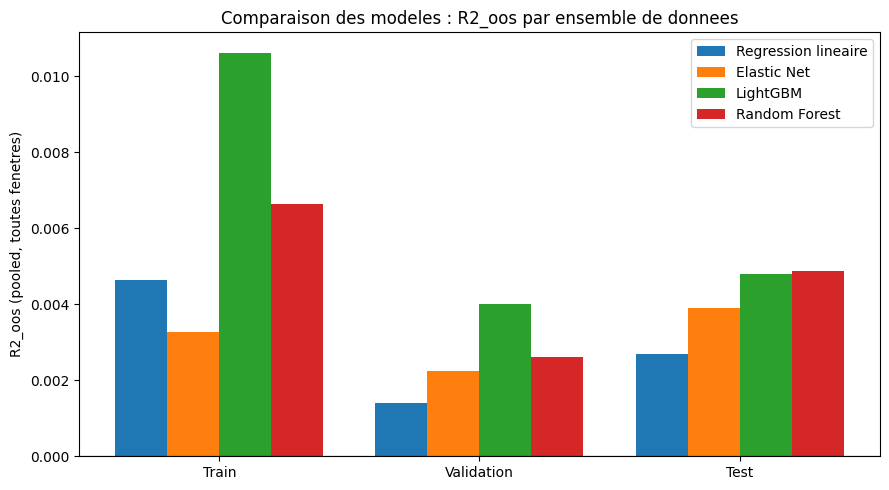

In [4]:
ensembles = ['r2_oos_train', 'r2_oos_validation', 'r2_oos_test']
etiquettes = ['Train', 'Validation', 'Test']

fig, ax = plt.subplots(figsize=(9, 5))

largeur_barre = 0.8 / len(resultats)   # s'adapte automatiquement au nombre de modeles
positions = range(len(ensembles))

for i, (_, ligne) in enumerate(resultats.iterrows()):
    valeurs = [ligne[col] for col in ensembles]
    decalage = [p + i * largeur_barre for p in positions]
    ax.bar(decalage, valeurs, width=largeur_barre, label=ligne['modele'])

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks([p + largeur_barre * (len(resultats) - 1) / 2 for p in positions])
ax.set_xticklabels(etiquettes)
ax.set_ylabel("R2_oos (pooled, toutes fenetres)")
ax.set_title("Comparaison des modeles : R2_oos par ensemble de donnees")
ax.legend()
plt.tight_layout()

plt.savefig(config.FICHIER_COMPARAISON_PNG, dpi=150)
plt.show()

### A.5 Évolution du R²_oos test au fil des fenêtres, par modèle

Les fenêtres glissantes/extensives permettent de voir **quand** chaque modèle est bon ou
mauvais — utile pour repérer des périodes difficiles pour tous les modèles à la fois (crises,
changements de régime de marché) plutôt que des différences propres à un seul modèle.

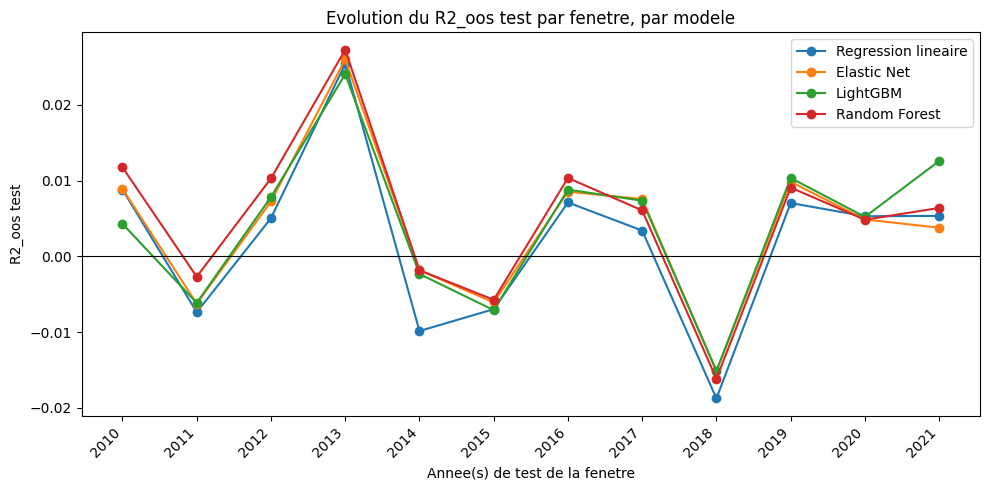

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

for nom, chemin in fichiers_resultats_par_fenetre.items():
    detail = pd.read_parquet(chemin)
    ax.plot(detail['annee_test'], detail['r2_oos_test'], marker='o', label=nom)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel("Annee(s) de test de la fenetre")
ax.set_ylabel("R2_oos test")
ax.set_title("Evolution du R2_oos test par fenetre, par modele")
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(config.FICHIER_EVOLUTION_R2_PNG, dpi=150)
plt.show()

In [6]:
resultats.to_parquet(config.FICHIER_COMPARAISON_PARQUET, index=False)
print("Comparaison sauvegardee   :", config.FICHIER_COMPARAISON_PARQUET)
print("Graphique sauvegarde      :", config.FICHIER_COMPARAISON_PNG)
print("Evolution par fenetre     :", config.FICHIER_EVOLUTION_R2_PNG)

Comparaison sauvegardee   : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\comparaison_modeles.parquet
Graphique sauvegarde      : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\comparaison_modeles.png
Evolution par fenetre     : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\evolution_r2_oos_par_fenetre.png


## Partie B — Portefeuilles long-short par décile

Le `R²_oos` mesure la précision statistique d'un modèle, mais ne dit rien directement de sa
**valeur économique** : un modèle peut avoir un `R²_oos` légèrement supérieur à un autre tout
en produisant une stratégie d'investissement moins intéressante (moins stable, plus risquée...),
ou inversement. Cette partie traduit les prédictions des 4 modèles en portefeuilles
investissables, pour juger cette valeur économique directement — avec les mesures qu'utilisent
les praticiens de la finance quantitative.

1. Charger les prédictions de test déjà sauvegardées par les notebooks 04 à 07
   (`outputs/predictions_*.parquet`) — **sans aucun ré-entraînement, ni aucun rechargement de
   modèle**
2. Fusionner les 4 tables de prédictions sur `(permno, annee_mois)` en une seule
3. Construire, **mois par mois**, 10 portefeuilles par décile de rendement prédit, en
   pondération égale — la méthode standard en finance quantitative empirique (Fama-French,
   Gu, Kelly & Xiu 2020...) pour transformer un pouvoir prédictif statistique en stratégie
   d'investissement concrète
4. Former le portefeuille **long-short** de chaque modèle : acheter le décile le plus élevé
   (rendement prédit le plus fort), vendre à découvert le décile le plus faible
5. Évaluer chaque portefeuille avec des mesures de performance utilisées en finance
   quantitative : rendement annualisé, volatilité annualisée, ratio de Sharpe, ratio de
   Sortino, drawdown maximum, significativité statistique...

ℹ️ **Sur la période couverte** : avec les fenêtres glissantes/extensives, la période de
« test » n'est plus un seul bloc à la fin du panel, mais **l'union de tous les tests de
toutes les fenêtres** — potentiellement plusieurs décennies mises bout à bout (voir le
résumé des fenêtres au notebook 04, section 1). C'est *plus* représentatif d'une vraie
stratégie d'investissement suivie sur le long terme qu'un seul test récent.

### B.1 Chargement et fusion des prédictions déjà sauvegardées

Chaque fichier `predictions_*.parquet` contient une ligne par `(permno, annee_mois)` de test
(toutes fenêtres confondues pour ce modèle), avec le rendement réellement réalisé
(`excess_return`) et la prédiction du modèle. Les 4 modèles utilisant exactement les mêmes
fenêtres (mêmes paramètres dans `config.py`), leurs 4 tables de test devraient couvrir
exactement les mêmes `(permno, annee_mois)` — on le vérifie avant de fusionner.

In [7]:
tables_predictions = {}
for nom, (cle, chemin) in fichiers_predictions.items():
    table = pd.read_parquet(chemin)
    tables_predictions[cle] = table
    print(f"{nom:22s} : {table.shape}, periode {table['annee_mois'].min()} a {table['annee_mois'].max()}")

Regression lineaire    : (669550, 5), periode 201001 a 202112
Elastic Net            : (669550, 5), periode 201001 a 202112
LightGBM               : (669550, 5), periode 201001 a 202112
Random Forest          : (669550, 5), periode 201001 a 202112


In [8]:
# On part de la 1ere table (identifiants + cible) et on ajoute la colonne de prediction
# de chaque modele par une fusion sur (permno, annee_mois) -- 'inner' par securite, au cas
# ou une fenetre de bord differerait legerement d'un modele a l'autre.
cible = config.CIBLE
predictions = None

for nom, (cle, _) in fichiers_predictions.items():
    table = tables_predictions[cle][['permno', 'annee_mois', cible, 'prediction']].rename(
        columns={'prediction': f'pred_{cle}'}
    )
    if predictions is None:
        predictions = table
    else:
        predictions = pd.merge(
            predictions, table.drop(columns=[cible]),
            on=['permno', 'annee_mois'], how='inner',
        )

print(f"Predictions fusionnees : {predictions.shape}")
print(f"Periode couverte : {predictions['annee_mois'].min()} a {predictions['annee_mois'].max()}")
print(f"Nombre de mois distincts : {predictions['annee_mois'].nunique()}")
print(f"Nombre d'entreprises (permno) distinctes : {predictions['permno'].nunique()}")
predictions.head()

Predictions fusionnees : (669550, 7)
Periode couverte : 201001 a 202112
Nombre de mois distincts : 144
Nombre d'entreprises (permno) distinctes : 10080


,permno,annee_mois,excess_return,pred_reg_lineaire,pred_elastic_net,pred_lightgbm,pred_random_forest
0,10001,201001,-0.018932,0.005855,0.005752,0.018103,0.005638
1,10002,201001,0.365854,-0.011612,-0.011081,-0.033810,-0.006516
2,10025,201001,-0.088036,0.016756,0.016380,0.017784,0.014089
3,10026,201001,0.046296,-0.000642,-0.000563,0.002423,0.003607
4,10032,201001,0.194171,0.016989,0.016626,0.009293,0.010669


### B.3 Construction des portefeuilles par décile (mois par mois)

Pour chaque modèle et **chaque mois séparément**, on classe les entreprises en 10 groupes
(déciles) selon leur rendement prédit :
- **décile 1** : les prédictions les plus faibles (le modèle anticipe les moins bonnes
  performances)
- **décile 10** : les prédictions les plus élevées (le modèle anticipe les meilleures
  performances)

⚠️ **Pourquoi classer mois par mois, et pas sur toute la période d'un coup ?** Un décile doit
représenter un portefeuille qu'on pourrait *réellement* construire à un instant donné, avec
les entreprises disponibles *ce mois-là*. Classer sur l'ensemble de la période mélangerait des
entreprises de mois différents dans un même "portefeuille", ce qui n'aurait aucun sens
opérationnel.

ℹ️ On utilise `rank(method='first')` avant `qcut` : ça garantit exactement 10 groupes de
taille quasi identique chaque mois, même s'il existe des prédictions strictement égales
(rares mais possibles) — un `qcut` direct sur les prédictions brutes peut échouer ou produire
moins de 10 groupes en présence d'égalités.

In [9]:
NB_DECILES = config.NB_DECILES  # 10 par defaut

# ℹ️ `assigner_decile` (et tout le reste de la partie B) vit desormais dans portefeuilles.py,
# a la racine du projet, plutot que dans cette cellule : la MEME logique est reutilisee par
# scripts/etape10_analyse_par_taille.py, qui refait exactement ces portefeuilles a
# l'interieur de chaque segment de capitalisation (voir notebook 10). Le calcul est
# strictement identique a ce qu'il etait ici.
#
# On garde le nom court disponible dans tout le notebook (il resservait en partie C).
assigner_decile = portefeuilles.assigner_decile

for nom, (cle, _) in fichiers_predictions.items():
    predictions[f'decile_{cle}'] = portefeuilles.assigner_deciles_par_mois(
        predictions, f'pred_{cle}', n=NB_DECILES,
    )

print("Deciles assignes pour les 4 modeles.")
print()
print("Verification : nombre moyen d'entreprises par decile et par mois (doit etre stable "
      "et similaire entre deciles) :")
for nom, (cle, _) in fichiers_predictions.items():
    taille_moyenne = predictions.groupby(['annee_mois', f'decile_{cle}']).size().groupby('annee_mois').mean().mean()
    print(f"  {nom:22s} : ~{taille_moyenne:.0f} entreprises par decile en moyenne chaque mois")

Deciles assignes pour les 4 modeles.

Verification : nombre moyen d'entreprises par decile et par mois (doit etre stable et similaire entre deciles) :
  Regression lineaire    : ~465 entreprises par decile en moyenne chaque mois
  Elastic Net            : ~465 entreprises par decile en moyenne chaque mois
  LightGBM               : ~465 entreprises par decile en moyenne chaque mois
  Random Forest          : ~465 entreprises par decile en moyenne chaque mois


### B.4 Rendement mensuel de chaque décile, et portefeuille long-short

Pour chaque modèle, le rendement d'un décile un mois donné est la **moyenne équipondérée**
du rendement (réellement réalisé, pas prédit) des entreprises classées dans ce décile ce
mois-là. Le portefeuille **long-short** achète le décile 10 et vend à découvert le décile 1 :
son rendement mensuel est simplement la différence des deux.

C'est la construction standard d'un "portefeuille de spread" en finance quantitative
empirique : si le modèle a un vrai pouvoir prédictif, ce portefeuille doit dégager un
rendement positif et statistiquement significatif, sans qu'on ait besoin de connaître le
signe ou l'ampleur exacte du rendement du marché.

In [10]:
rendements_deciles = {}   # cle -> DataFrame (index=annee_mois, colonnes=1..NB_DECILES)
rendements_ls = {}        # cle -> Series (index=annee_mois), portefeuille long-short

for nom, (cle, _) in fichiers_predictions.items():
    tableau = portefeuilles.rendements_par_decile(predictions, f'decile_{cle}', cible)
    rendements_deciles[cle] = tableau
    rendements_ls[cle] = portefeuilles.rendement_long_short(tableau, nb_deciles=NB_DECILES)

rendements_portefeuilles = pd.DataFrame({
    nom: rendements_ls[cle] for nom, (cle, _) in fichiers_predictions.items()
})

print("Rendements mensuels des portefeuilles long-short (decile 10 - decile 1), extrait :")
rendements_portefeuilles.head()

Rendements mensuels des portefeuilles long-short (decile 10 - decile 1), extrait :


,Regression lineaire,Elastic Net,LightGBM,Random Forest
annee_mois,,,,
201001,-0.006718,-0.006398,-0.001864,-0.011493
201002,0.038495,0.039994,0.015247,0.026348
201003,0.023871,0.021933,0.034402,0.030262
201004,0.012254,0.013657,0.053978,0.013037
201005,0.009469,0.011958,0.021653,0.038385


### B.5 Mesures de performance financière

On calcule, pour chaque portefeuille long-short, un ensemble de mesures standard en finance
quantitative :

- **Rendement annualisé** : moyenne mensuelle × 12
- **Volatilité annualisée** : écart-type mensuel × √12
- **Ratio de Sharpe** : rendement annualisé / volatilité annualisée. Comme `excess_return`
  est déjà un rendement *excédentaire* (net du taux sans risque, voir notebook 03,
  partie A), on n'a
  pas besoin de soustraire à nouveau `Rfree` : le ratio de Sharpe se calcule directement.
- **Ratio de Sortino** : comme le Sharpe, mais ne pénalise que la volatilité *à la baisse*
  (les mois négatifs) — plus pertinent quand les rendements ne sont pas symétriques.
- **Drawdown maximum** : la pire perte cumulée observée depuis un sommet de richesse
  antérieur, sur toute la période de test.
- **% de mois positifs** : proportion de mois où le portefeuille long-short a un rendement
  positif.
- **t-stat / p-value** : test de significativité du rendement moyen (H0 : rendement moyen
  nul). Un t-stat au-delà de ~2 (en valeur absolue) est généralement considéré comme
  significatif.
- **Asymétrie (skewness) et aplatissement (kurtosis)** : les rendements de portefeuilles
  long-short sont rarement gaussiens — utile pour juger si le Sharpe seul suffit à décrire le
  profil de risque.

In [11]:
calculer_metriques = portefeuilles.calculer_metriques

print("Mesures de performance :", ", ".join(portefeuilles.calculer_metriques(
    rendements_portefeuilles.iloc[:, 0]).keys()))

Mesures de performance : rendement_annualise, volatilite_annualisee, sharpe_ratio, sortino_ratio, max_drawdown, pct_mois_positifs, t_stat, p_value, skewness, kurtosis, n_mois


In [12]:
performance = pd.DataFrame({
    nom: calculer_metriques(rendements_portefeuilles[nom])
    for nom, _ in fichiers_predictions.items()
}).T

performance = performance.sort_values('sharpe_ratio', ascending=False)

# 'cle_experience' identifie, pour CHAQUE modele, A QUEL lancement de 04/05/06/07 (quels
# parametres generaux + specifiques) ces predictions -- et donc ces mesures de portefeuille
# -- correspondent : la MEME cle deja ecrite dans outputs/resultats_*.parquet (voir
# notebooks 04-07, section 7, et journal.cle_experience_actuelle). Sauvegardee plus bas
# (B.8) dans outputs/performance_portefeuilles.parquet : c'est ce qui permet au notebook 09
# de relier CES mesures a LA BONNE ligne de son tableau de comparaison (voir sa section 2).
performance['cle_experience'] = resultats.set_index('modele')['cle_experience']

print("Performance des portefeuilles long-short (decile 10 - decile 1), par modele :")
performance.drop(columns='cle_experience').round(4)

Performance des portefeuilles long-short (decile 10 - decile 1), par modele :


,rendement_annualise,volatilite_annualisee,sharpe_ratio,sortino_ratio,max_drawdown,pct_mois_positifs,t_stat,p_value,skewness,kurtosis,n_mois
Regression lineaire,0.1268,0.1039,1.2200,2.2469,-0.1134,0.6597,4.2261,0.0000,-0.0959,0.6942,144.0
LightGBM,0.1576,0.1297,1.2152,2.4137,-0.1986,0.6319,4.2096,0.0000,0.2100,0.1440,144.0
Random Forest,0.1559,0.1377,1.1320,2.2090,-0.2094,0.6319,3.9214,0.0001,0.2552,0.1673,144.0
Elastic Net,0.1036,0.1353,0.7657,1.2808,-0.1975,0.5903,2.6524,0.0089,-0.0895,0.0125,144.0


### B.6 Le rendement est-il monotone par décile ? (diagnostic de qualité du signal)

Un signe de bonne qualité du signal prédictif : le rendement moyen des déciles devrait
**augmenter globalement du décile 1 au décile 10**. Si le classement du modèle n'a aucune
valeur, les rendements moyens par décile devraient être plats (à peu près identiques quel
que soit le décile) plutôt que croissants.

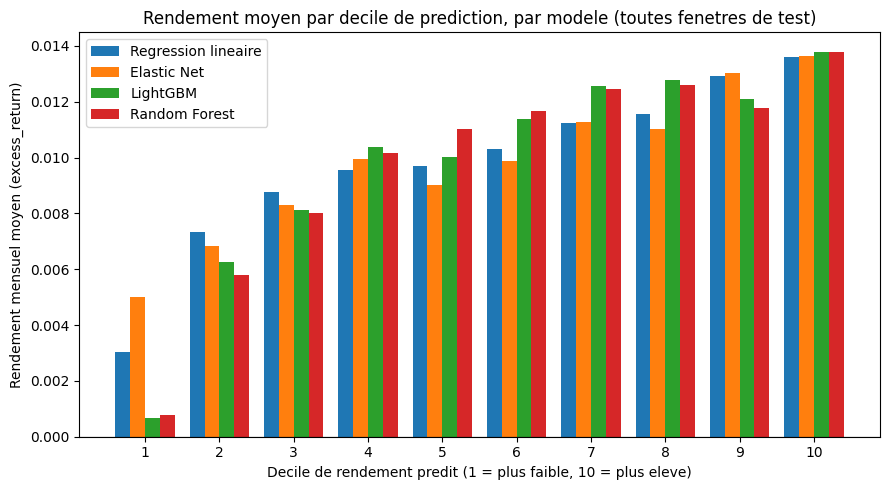

In [13]:
rendement_moyen_par_decile = pd.DataFrame({
    nom: rendements_deciles[cle].mean()
    for nom, (cle, _) in fichiers_predictions.items()
})
rendement_moyen_par_decile.index.name = 'decile'

fig, ax = plt.subplots(figsize=(9, 5))

largeur_barre = 0.8 / len(fichiers_predictions)   # s'adapte au nombre de modeles
positions = np.arange(NB_DECILES)

for i, (nom, _) in enumerate(fichiers_predictions.items()):
    valeurs = rendement_moyen_par_decile[nom].values
    decalage = positions + i * largeur_barre
    ax.bar(decalage, valeurs, width=largeur_barre, label=nom)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(positions + largeur_barre * (len(fichiers_predictions) - 1) / 2)
ax.set_xticklabels(range(1, NB_DECILES + 1))
ax.set_xlabel("Decile de rendement predit (1 = plus faible, 10 = plus eleve)")
ax.set_ylabel("Rendement mensuel moyen (excess_return)")
ax.set_title("Rendement moyen par decile de prediction, par modele (toutes fenetres de test)")
ax.legend()
plt.tight_layout()

plt.savefig(config.FICHIER_DECILES_PNG, dpi=150)
plt.show()

### B.8 Benchmarks — à quoi se comparent ces portefeuilles ?

Deux repères construits sur **les mêmes mois et le même univers**, sans aucune prédiction :

- **Univers équipondéré** : rendement moyen de tous les titres. Le « ne rien faire ».
- **Univers pondéré par la capitalisation** : proxy du marché, celui auquel se réfère un
  praticien. Il diffère nettement du précédent, les small caps y pesant beaucoup moins.

⚠️ Les deux sont **long only** et portent l'exposition au marché que le long-short neutralise.
Ils ne se comparent donc pas terme à terme aux portefeuilles de B.5 : ils donnent l'échelle
des rendements disponibles sur cette période, pas une performance à battre.

In [14]:
# ⚠️ Tableau SEPARE de `performance` : les benchmarks ne sont pas des modeles et n'ont pas
# de cle_experience. Les fusionner polluerait le journal et le notebook 09.

# --- Benchmark 1 : univers equipondere (LONG ONLY, "ne rien faire") ---
rendement_univers = predictions.groupby('annee_mois')[cible].mean()

# --- Benchmark 2 : univers pondere par la capitalisation (LONG ONLY, proxy du marche) ---
capitalisations = pd.read_parquet(
    config.FICHIER_PANEL_MODELISATION,
    columns=['permno', 'annee_mois', config.COLONNE_MVEL1_BRUT])
capitalisations['annee_mois'] = capitalisations['annee_mois'].astype(str)

univers = predictions[['permno', 'annee_mois', cible]].copy()
univers['annee_mois'] = univers['annee_mois'].astype(str)
univers = univers.merge(capitalisations, on=['permno', 'annee_mois'], how='left')
univers = univers.dropna(subset=[config.COLONNE_MVEL1_BRUT])

numerateur = (univers[cible] * univers[config.COLONNE_MVEL1_BRUT]).groupby(
    univers['annee_mois']).sum()
denominateur = univers[config.COLONNE_MVEL1_BRUT].groupby(univers['annee_mois']).sum()
rendement_univers_capi = numerateur / denominateur

benchmarks = pd.DataFrame({
    'Univers equipondere':  calculer_metriques(rendement_univers),
    'Univers pondere capi': calculer_metriques(rendement_univers_capi),
}).T

print("Benchmarks — memes mois, meme univers, aucune prediction de modele :")
print("⚠️ Tous deux LONG ONLY : ils portent l'exposition au marche que le long-short annule.")
display(benchmarks.round(4))

benchmarks.to_parquet(config.FICHIER_BENCHMARKS)

Benchmarks — memes mois, meme univers, aucune prediction de modele :
⚠️ Tous deux LONG ONLY : ils portent l'exposition au marche que le long-short annule.


,rendement_annualise,volatilite_annualisee,sharpe_ratio,sortino_ratio,max_drawdown,pct_mois_positifs,t_stat,p_value,skewness,kurtosis,n_mois
Univers equipondere,0.1176,0.1795,0.6552,1.0118,-0.3318,0.6667,2.2699,0.0247,-0.3975,3.6980,144.0
Univers pondere capi,0.1351,0.1443,0.9366,1.5131,-0.2142,0.7153,3.2443,0.0015,-0.3690,1.4919,144.0


### B.8 Richesse cumulée des 4 portefeuilles long-short

On trace la richesse cumulée (base 1, sans capital additionnel ni retrait) de chaque
portefeuille long-short sur toute la période de test (toutes fenêtres mises bout à bout),
pour visualiser à la fois la performance globale et la régularité (ou l'irrégularité) des
gains dans le temps.

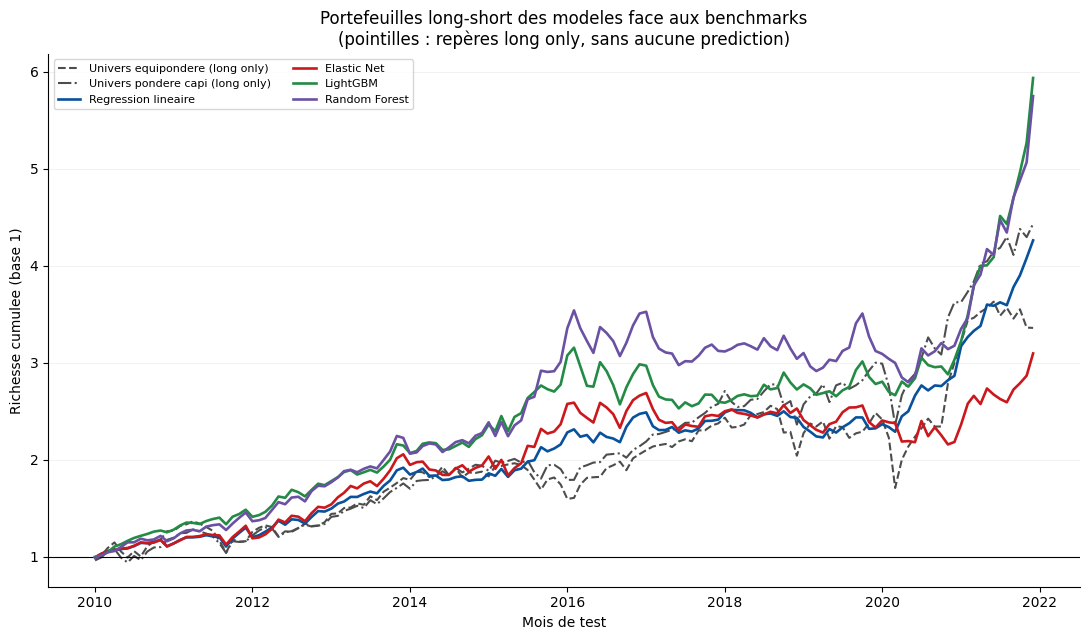

In [15]:
TAILLE_FIGURE = (11, 6.5)
ECHELLE_LOG = False    # True = compare les taux de croissance plutot que les niveaux

COULEURS_MODELES = ['#08519c', '#cb181d', '#238b45', '#6a51a3']

def en_dates(index):
    # `annee_mois` est une chaine : sans conversion, matplotlib pose un tick par mois.
    return pd.to_datetime(pd.Index(index).astype(str), format='%Y%m')

fig, ax = plt.subplots(figsize=TAILLE_FIGURE)

# --- Les deux univers : LONG ONLY, donc exposition au marche non neutralisee ---
for serie, etiquette, style in [
    (rendement_univers,      "Univers equipondere (long only)",   '--'),
    (rendement_univers_capi, "Univers pondere capi (long only)",  '-.'),
]:
    richesse = (1 + serie).cumprod()
    ax.plot(en_dates(richesse.index), richesse.values, label=etiquette,
            color='0.30', linewidth=1.5, linestyle=style, zorder=2)

# --- Les 4 modeles : trait plein ---
for i, (nom, _) in enumerate(fichiers_predictions.items()):
    richesse = (1 + rendements_portefeuilles[nom]).cumprod()
    ax.plot(en_dates(richesse.index), richesse.values, label=nom,
            color=COULEURS_MODELES[i % len(COULEURS_MODELES)],
            linewidth=1.9, zorder=5)

ax.axhline(1, color='black', linewidth=0.8)
if ECHELLE_LOG:
    ax.set_yscale('log')
ax.set_ylabel("Richesse cumulee (base 1)")
ax.set_xlabel("Mois de test")
ax.set_title("Portefeuilles long-short des modeles face aux benchmarks\n"
             "(pointilles : repères long only, sans aucune prediction)", fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='upper left')
ax.grid(axis='y', alpha=0.2, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(config.FICHIER_BENCHMARKS_PNG, dpi=150)
plt.show()

### B.8 Comparaison finale et sauvegarde

⚠️ Comme pour le `R²_oos` en partie A, un ratio de Sharpe élevé ne dit rien à lui seul de
la qualité *économique* du modèle sans regarder aussi le drawdown maximum et la
significativité statistique (`t_stat` / `p_value`) : un Sharpe flatteur porté par 2-3 mois
exceptionnels sur une courte période de test n'a pas la même valeur qu'un Sharpe plus modeste
mais régulier sur une longue période.

ℹ️ **A noter** : en plus du simple instantané `outputs/performance_portefeuilles.parquet`
(écrasé à chaque lancement), ces mesures sont aussi **ajoutées** à
`outputs/historique_performance_portefeuilles.parquet` -- un fichier **jamais écrasé**
(comme `outputs/journal_experiences.parquet`), dédupliqué par `cle_experience` (voir B.5 et
`journal.enregistrer_performances_portefeuilles`) : relancer 08 sur les mêmes prédictions
n'y ajoute rien de plus, mais un changement de modèle/paramètres suivi d'un nouveau
lancement de 08 y **ajoute** une ligne sans supprimer celle du lancement précédent. C'est
cet historique que le notebook 09 utilise pour afficher le Sharpe (etc.) de **chaque**
expérience du journal déjà évaluée par 08 au moins une fois -- `NaN` uniquement pour celles
qui n'ont encore jamais été évaluées (voir sa section 2).

In [16]:
meilleur_modele = performance['sharpe_ratio'].idxmax()
print(f"Meilleur portefeuille long-short sur TEST (ratio de Sharpe) : {meilleur_modele} "
      f"(Sharpe = {performance.loc[meilleur_modele, 'sharpe_ratio']:.3f})")
print()
print(performance.drop(columns='cle_experience').loc[meilleur_modele].round(4))

Meilleur portefeuille long-short sur TEST (ratio de Sharpe) : Regression lineaire (Sharpe = 1.220)

rendement_annualise        0.1268
volatilite_annualisee      0.1039
sharpe_ratio               1.2200
sortino_ratio              2.2469
max_drawdown              -0.1134
pct_mois_positifs          0.6597
t_stat                     4.2261
p_value                    0.0000
skewness                  -0.0959
kurtosis                   0.6942
n_mois                   144.0000
Name: Regression lineaire, dtype: float64


In [17]:
rendements_portefeuilles.to_parquet(config.FICHIER_RENDEMENTS_PORTEFEUILLES)
performance.to_parquet(config.FICHIER_PERFORMANCE_PORTEFEUILLES)

print("Rendements mensuels sauvegardes  :", config.FICHIER_RENDEMENTS_PORTEFEUILLES)
print("Tableau de performance sauvegarde:", config.FICHIER_PERFORMANCE_PORTEFEUILLES)
print("Graphique par decile sauvegarde  :", config.FICHIER_DECILES_PNG)
print("Graphique richesse cumulee sauve :", config.FICHIER_CUMULATIF_PNG)

# On AJOUTE (sans rien ecraser) ces mesures a l'historique cumulatif -- voir B.8
# ci-dessus et journal.py. Dedupliqué par cle_experience : relancer 08 sur les memes
# predictions n'ajoute rien de plus.
print()
journal.enregistrer_performances_portefeuilles(performance)
print("Historique cumulatif (jamais ecrase) :", config.FICHIER_HISTORIQUE_PERFORMANCE_PORTEFEUILLES)

Rendements mensuels sauvegardes  : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\rendements_portefeuilles_deciles.parquet
Tableau de performance sauvegarde: C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\performance_portefeuilles.parquet
Graphique par decile sauvegarde  : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\portefeuilles_rendement_par_decile.png
Graphique richesse cumulee sauve : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\portefeuilles_richesse_cumulee.png

Historique des performances de portefeuille : rien de nouveau (toutes les experiences de ce lancement y figurent deja).
Historique cumulatif (jamais ecrase) : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\historique_performance_portefeuilles.parquet


### B.9 Constructions alternatives — de combien le Sharpe bouge-t-il ?

Tout ce qui précède repose sur **une** construction : long-short **équipondéré**, décile 10
moins décile 1, recalculé mois par mois. C'est la référence du projet, et rien de ce qui suit
ne la remplace — le tableau de performance sauvegardé en B.8 et le journal des expériences
continuent de porter sur elle seule.

Cette section rejoue **exactement les mêmes prédictions** (aucun ré-entraînement, aucun
fichier réécrit) sous d'autres constructions, pour répondre à une question simple : *quelle
part du Sharpe vient du modèle, et quelle part vient de la façon dont on transforme ses
prédictions en portefeuille ?* Deux leviers, combinés deux à deux :

| | Long-short (D10 − D1) | Long only (top *X* %) |
|---|---|---|
| **Équipondéré** | la référence du projet | ↓ |
| **Pondéré par la capitalisation** | → | les deux à la fois |

**Pondération par la capitalisation** (`config.PONDERATION_PAR_CAPITALISATION`). Un
portefeuille équipondéré met autant d'argent sur une micro-cap illiquide que sur Apple. Or
c'est précisément chez les petites capitalisations que les modèles d'apprentissage trouvent
l'essentiel de leur signal. Pondérer par `mvel1_brut` — la capitalisation du mois *t*, donc
connue au moment de la formation et sans information du futur — reflète où l'argent peut
**réellement** être investi. C'est le test de robustesse de Gu, Kelly & Xiu (2020) : le Sharpe
s'effondre généralement au passage. Si c'est le cas ici, ce n'est pas un échec, c'est un
résultat — et il recoupe directement le notebook 10 (analyse par taille).

**Long only** (`config.PCT_LONG_ONLY`, 20 % par défaut). Beaucoup d'investisseurs
institutionnels ne peuvent pas vendre à découvert : on achète les *X* % des titres les mieux
notés, sans jambe courte. ⚠️ **Ce portefeuille n'est pas comparable au long-short** : il porte
l'exposition au marché (bêta ≈ 1), que le long-short neutralise en grande partie. Son Sharpe
se lit contre celui du marché. Ce qu'il dit en revanche très bien : si le long-short brille
mais que le long only s'effondre, toute la performance vient de la **jambe courte** — donc
d'une stratégie que beaucoup ne peuvent pas mettre en œuvre.

⚠️ **Aucun coût de transaction n'est déduit nulle part**, et ces constructions n'ont pas le
même turnover (le long only en a nettement moins que le long-short, qui doit refaire ses deux
jambes chaque mois). Le classement ci-dessous est **brut** : c'est la limite à énoncer
explicitement dans le mémoire.

In [18]:
# La capitalisation vit dans le PANEL (colonne ecrite par l'etape 03), pas dans les fichiers
# de predictions : il faut la fusionner. ⚠️ C'est `mvel1_brut`, la capitalisation AVANT
# winsorizing et rank transform -- `mvel1` vit dans [-1, 1] et ne serait pas un poids valide.
COLONNE_CAPI = config.COLONNE_MVEL1_BRUT

predictions_alt = predictions.copy()
predictions_alt['annee_mois'] = predictions_alt['annee_mois'].astype(str)
colonne_poids = None

if config.PONDERATION_PAR_CAPITALISATION:
    capitalisations = pd.read_parquet(
        config.FICHIER_PANEL_MODELISATION, columns=['permno', 'annee_mois', COLONNE_CAPI])
    capitalisations['annee_mois'] = capitalisations['annee_mois'].astype(str)
    predictions_alt = predictions_alt.merge(
        capitalisations, on=['permno', 'annee_mois'], how='left')
    colonne_poids = COLONNE_CAPI

    pct_manquant = float(predictions_alt[COLONNE_CAPI].isna().mean() * 100)
    print(f"Capitalisation fusionnee : {100 - pct_manquant:.1f} % des lignes renseignees.")
    if pct_manquant > 5:
        print(f"⚠️ {pct_manquant:.1f} % de capitalisations manquantes. Les portefeuilles")
        print("   ponderes ecartent ces lignes : ils ne portent donc pas exactement sur le")
        print("   meme univers que les equiponderes, et l'ecart de Sharpe melange alors deux")
        print("   effets. A verifier avant de conclure quoi que ce soit.")
else:
    print("config.PONDERATION_PAR_CAPITALISATION = False :")
    print("  seules les variantes equiponderees sont calculees.")

print(f"Long only : les {config.PCT_LONG_ONLY * 100:.0f} % des titres les mieux notes "
      f"(~{config.PCT_LONG_ONLY * NB_DECILES:.0f} deciles sur {NB_DECILES}).")

Capitalisation fusionnee : 100.0 % des lignes renseignees.
Long only : les 20 % des titres les mieux notes (~2 deciles sur 10).


In [19]:
# ⚠️ MEMES predictions, MEME cible, MEMES mois : tout ecart de Sharpe entre deux lignes vient
# uniquement de la construction du portefeuille, jamais du modele. C'est ce qui rend ce
# tableau lisible -- et c'est pour cela qu'aucun ré-entrainement n'est necessaire.
comparaisons = {}
for nom, (cle, _) in fichiers_predictions.items():
    comparaisons[nom] = portefeuilles.comparer_constructions(
        predictions_alt,
        colonne_prediction=f'pred_{cle}',
        colonne_cible=cible,
        nb_deciles=NB_DECILES,
        colonne_poids=colonne_poids,
        pct_long_only=config.PCT_LONG_ONLY,
    )

performance_constructions = pd.concat(
    {nom: c['performance'] for nom, c in comparaisons.items()},
    names=['modele', 'construction'])

colonnes_alt = ['sharpe_ratio', 'pct_mois_positifs']
performance_constructions[colonnes_alt].round(4)

sharpe_ratio  pct_mois_positifs
modele              construction                                                   
Regression lineaire Long-short equipondere                1.2200             0.6597
                    Long only top 20% equipondere         0.8186             0.6597
                    Long-short pondere capi               0.8286             0.6250
                    Long only top 20% pondere capi        0.9384             0.6875
Elastic Net         Long-short equipondere                0.7657             0.5903
                    Long only top 20% equipondere         0.8337             0.6597
                    Long-short pondere capi               0.4321             0.5278
                    Long only top 20% pondere capi        0.9027             0.6528
LightGBM            Long-short equipondere                1.2152             0.6319
                    Long only top 20% equipondere         0.7394             0.6389
                    Long-short pondere capi               0.6076             0.5903
                    Long only top 20% pondere capi        0.8322             0.6458
Random Forest       Long-short equipondere                1.1320             0.6319
                    Long only top 20% equipondere         0.7492             0.6597
                    Long-short pondere capi               0.7281             0.6111
                    Long only top 20% pondere capi        0.8987             0.6389

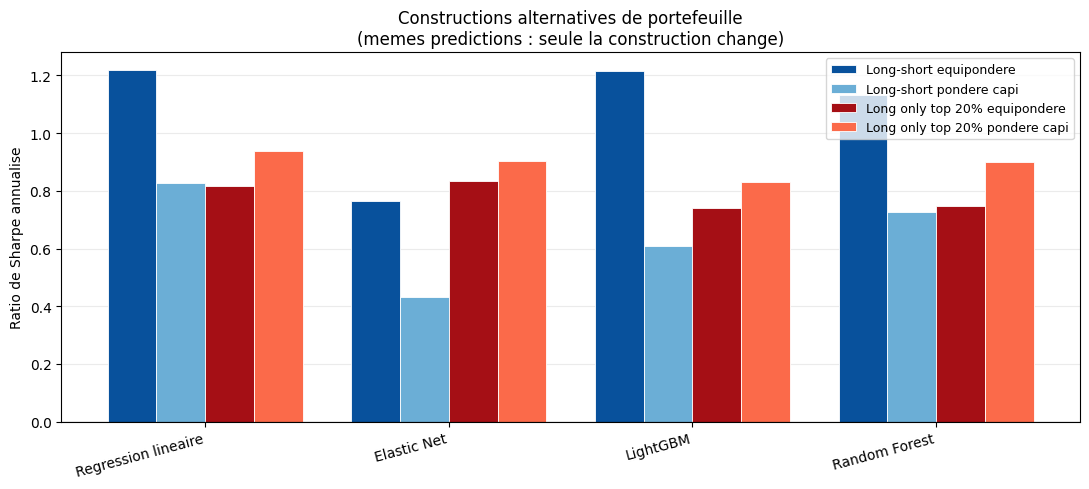

Ecart moyen de Sharpe par rapport a la construction de reference (Long-short equipondere) :
  Long-short pondere capi            : -0.434  (en dessous de la reference)
  Long only top 20% equipondere      : -0.298  (en dessous de la reference)
  Long only top 20% pondere capi     : -0.190  (en dessous de la reference)


In [20]:
# Le graphique qui resume la section : un groupe de barres par modele, une barre par
# construction. C'est la figure a mettre dans le memoire pour ce point.
tableau_sharpe = performance_constructions['sharpe_ratio'].unstack('construction')

TAILLE_FIGURE = (11, 5)

# L'etiquette du long only depend de config.PCT_LONG_ONLY : on la reconstruit plutot que
# de la coder en dur, sinon changer PCT_LONG_ONLY casse silencieusement l'ordre ci-dessous.
ETIQUETTE_LONG = f"Long only top {int(round(config.PCT_LONG_ONLY * 100))}%"

# Ordre voulu : les deux long-short d'abord, puis les deux long only.
ORDRE_CONSTRUCTIONS = [
    'Long-short equipondere',
    'Long-short pondere capi',
    f"{ETIQUETTE_LONG} equipondere",
    f"{ETIQUETTE_LONG} pondere capi",
]

# Long-short = bleus (fonce -> clair), long only = rouges (fonce -> clair).
COULEURS_CONSTRUCTIONS = {
    'Long-short equipondere':            '#08519c',
    'Long-short pondere capi':           '#6baed6',
    f"{ETIQUETTE_LONG} equipondere":     '#a50f15',
    f"{ETIQUETTE_LONG} pondere capi":    '#fb6a4a',
}

# Si PONDERATION_PAR_CAPITALISATION = False, seules 2 constructions existent : on ne garde
# que celles reellement presentes, sans planter.
constructions = [c for c in ORDRE_CONSTRUCTIONS if c in tableau_sharpe.columns]

fig, ax = plt.subplots(figsize=TAILLE_FIGURE)
largeur = 0.8 / len(constructions)
positions = np.arange(len(tableau_sharpe))

for i, construction in enumerate(constructions):
    ax.bar(positions + i * largeur, tableau_sharpe[construction].values,
           width=largeur, label=construction,
           color=COULEURS_CONSTRUCTIONS[construction],
           edgecolor='white', linewidth=0.6)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(positions + largeur * (len(constructions) - 1) / 2)
ax.set_xticklabels(tableau_sharpe.index, rotation=15, ha='right')
ax.set_ylabel("Ratio de Sharpe annualise")
ax.set_title("Constructions alternatives de portefeuille\n"
             "(memes predictions : seule la construction change)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.25, axis='y')
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(config.FICHIER_CONSTRUCTIONS_PNG, dpi=150)
plt.show()

REFERENCE = 'Long-short equipondere'
print(f"Ecart moyen de Sharpe par rapport a la construction de reference ({REFERENCE}) :")
for construction in constructions:
    if construction == REFERENCE:
        continue
    ecart = float((tableau_sharpe[construction] - tableau_sharpe[REFERENCE]).mean())
    signe = "au-dessus" if ecart > 0 else "en dessous"
    print(f"  {construction:34s} : {ecart:+.3f}  ({signe} de la reference)")

In [21]:
# ⚠️ Fichier SEPARE : `performance_portefeuilles.parquet` (sauvegarde en B.8) reste
# strictement inchange, ainsi que le journal des experiences. Ces constructions alternatives
# sont un diagnostic, pas une experience : elles ne portent aucune cle d'experience nouvelle
# puisqu'elles reposent sur les MEMES predictions que celles deja enregistrees.
performance_constructions.to_parquet(config.FICHIER_PERFORMANCE_CONSTRUCTIONS)
print("Constructions alternatives sauvegardees :", config.FICHIER_PERFORMANCE_CONSTRUCTIONS)
print("Graphique sauvegarde                    :", config.FICHIER_CONSTRUCTIONS_PNG)

Constructions alternatives sauvegardees : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\performance_constructions.parquet
Graphique sauvegarde                    : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\portefeuilles_constructions_alternatives.png


⚠️ Limites valables pour toute la partie : portefeuilles **bruts** de tout coût, et rendements
déjà excédentaires (nets du taux sans risque), d'où l'absence de soustraction supplémentaire
dans le ratio de Sharpe.

ℹ️ Les coûts ne sont plus absents du notebook pour autant : la **partie D** mesure le turnover
de ces mêmes portefeuilles, y applique des coûts de transaction différenciés par pondération
ainsi qu'un coût d'emprunt sur la jambe vendeuse, et calcule le coût à partir duquel chaque
stratégie cesse d'être rentable. Les chiffres de cette partie-ci restent la référence brute du
projet, à laquelle les chiffres nets se comparent.

## Partie C — Portefeuille combiné (ensemble de plusieurs modèles)

Les parties A et B répondent à « **quel** modèle choisir ? ». Cette partie pose une autre
question : et si on n'avait pas à choisir ?

**L'idée.** Deux modèles qui se trompent sur des choses **différentes** se complètent. La
moyenne de leurs prévisions a une erreur quadratique plus faible que chacune prise isolément,
même quand l'un des deux est nettement moins bon — c'est le résultat fondateur de
**Bates & Granger (1969)**, et c'est exactement l'argument de la diversification d'un
portefeuille, appliqué aux prévisions plutôt qu'aux actifs. Pour deux prévisions d'erreurs de
variances $\sigma_1^2$, $\sigma_2^2$ et de corrélation $\rho$, la combinaison de poids $w$ et
$1-w$ a une variance d'erreur

$$w^2\sigma_1^2 + (1-w)^2\sigma_2^2 + 2w(1-w)\rho\,\sigma_1\sigma_2$$

qui, pour un $w$ bien choisi, est **inférieure à $\min(\sigma_1^2,\sigma_2^2)$** dès que
$\rho$ est assez faible. D'où l'intérêt de combiner des familles **différentes** : une forêt
et un boosting se trompent différemment, deux Elastic Net aux `alpha` voisins non.

**Cinq méthodes de pondération**, toutes pilotées par `config.METHODE_PONDERATION_ENSEMBLE` :

| Méthode | Poids | Principe |
|---|---|---|
| `manuelle` | constants | ceux que tu fixes dans `config.POIDS_ENSEMBLE` |
| `egale` | constants | 1/N — la référence à battre (voir plus bas) |
| `r2_validation` | constants | ∝ au `R²_oos` de **validation** de chaque modèle |
| `inverse_variance` | variables | ∝ 1/EQM, ré-estimés chaque mois (Bates & Granger, 1969) |
| `moindres_carres` | variables | les poids qui minimisent l'erreur de la combinaison, ré-estimés chaque mois (Granger & Ramanathan, 1984 ; *stacking*) |

⚠️ **Le point critique : aucune fuite de données.** Les poids appliqués au mois *t* ne sont
jamais estimés en utilisant le mois *t* lui-même, ni aucun mois postérieur — uniquement les
mois strictement antérieurs (au plus `FENETRE_PONDERATION_ENSEMBLE_MOIS` d'entre eux). Un
portefeuille combiné construit avec les poids optimaux calculés sur **toute** la période de
test afficherait un Sharpe flatteur et parfaitement irréalisable : c'est l'erreur classique de
cet exercice. Les tout premiers mois, faute d'historique suffisant
(`MOIS_MINIMUM_PONDERATION_ENSEMBLE`), retombent sur des poids égaux.

In [22]:
# --- Configuration de l'ensemble (config.py, section "Portefeuille COMBINE") ---
modeles_ensemble = ensemble.verifier_configuration(list(fichiers_predictions))
cle_par_modele = {nom: cle for nom, (cle, _) in fichiers_predictions.items()}
colonnes_par_modele = {m: f'pred_{cle_par_modele[m]}' for m in modeles_ensemble}

print(f"Modeles combines : {modeles_ensemble}")
print(f"Methode de ponderation : {config.METHODE_PONDERATION_ENSEMBLE}")
print(f"  -> {ensemble.description()}")
if config.METHODE_PONDERATION_ENSEMBLE in ensemble.METHODES_GLISSANTES:
    fenetre = config.FENETRE_PONDERATION_ENSEMBLE_MOIS
    print(f"  Fenetre d'estimation : {fenetre if fenetre else 'tout l historique passe'} mois")
    print(f"  Historique minimum   : {config.MOIS_MINIMUM_PONDERATION_ENSEMBLE} mois "
          "(avant : poids egaux)")
if config.METHODE_PONDERATION_ENSEMBLE == 'moindres_carres':
    print(f"  Poids contraints >= 0 et de somme 1 : {config.POIDS_ENSEMBLE_POSITIFS}")

Modeles combines : ['LightGBM', 'Random Forest', 'Regression lineaire', 'Elastic Net']
Methode de ponderation : moindres_carres
  -> poids de moindres carres (Granger & Ramanathan 1984 / stacking), ré-estimes chaque mois sur les mois de test deja passes
  Fenetre d'estimation : 60 mois
  Historique minimum   : 24 mois (avant : poids egaux)
  Poids contraints >= 0 et de somme 1 : True


### C.1 Calcul des poids

Pour les deux méthodes glissantes, les poids sont ré-estimés **mois par mois**. Le calcul
passe par les matrices de produits croisés de chaque mois, cumulées sur la fenêtre : on ne
retouche jamais aux lignes individuelles, seulement à des matrices *k × k* (*k* = nombre de
modèles combinés). C'est ce qui rend l'estimation instantanée même sur des centaines de
milliers de lignes (voir `ensemble.py`).

In [23]:
modeles_ensemble = ensemble.verifier_configuration(list(fichiers_predictions))
cle_par_modele = {nom: cle for nom, (cle, _) in fichiers_predictions.items()}
colonnes_par_modele = {m: f'pred_{cle_par_modele[m]}' for m in modeles_ensemble}
scores_validation = resultats.set_index('modele')['r2_oos_validation'].to_dict()

comparaison_ensembles = ensemble.comparer_methodes(
    predictions, colonnes_par_modele, cible, nb_deciles=NB_DECILES,
    methodes=config.METHODES_ENSEMBLE_COMPAREES,
    scores_validation=scores_validation,
    fenetre_mois=config.FENETRE_PONDERATION_ENSEMBLE_MOIS,
    mois_minimum=config.MOIS_MINIMUM_PONDERATION_ENSEMBLE,
    positifs=config.POIDS_ENSEMBLE_POSITIFS,
)
methodes_ensemble = comparaison_ensembles['methodes']

print(f"Modeles combines ({len(modeles_ensemble)}) : {modeles_ensemble}")
print(f"Methode de reference (journal) : {config.METHODE_PONDERATION_ENSEMBLE}")
print()
print("Poids MOYEN de chaque modele sur la periode, par methode de ponderation :")
display(comparaison_ensembles['poids_moyens'].round(3))

Modeles combines (4) : ['LightGBM', 'Random Forest', 'Regression lineaire', 'Elastic Net']
Methode de reference (journal) : moindres_carres

Poids MOYEN de chaque modele sur la periode, par methode de ponderation :


,egale,r2_validation,inverse_variance,moindres_carres
LightGBM,0.25,0.390,0.25,0.242
Random Forest,0.25,0.254,0.25,0.579
Regression lineaire,0.25,0.137,0.25,0.055
Elastic Net,0.25,0.218,0.25,0.123


### C.2 Évolution des poids dans le temps

Mêmes modèles, mêmes prédictions : seule la règle de pondération change d'un panneau à
l'autre. Le trait pointillé marque la fin du démarrage, avant lequel les méthodes glissantes
retombent volontairement sur des poids égaux, faute d'historique.

- **`egale`** : 1/N, aucun paramètre estimé. La référence à battre.
- **`r2_validation`** : plat et quasi identique à `egale` — les R² de validation des deux
  modèles sont trop proches pour les départager.
- **`inverse_variance`** : plat aussi, mais pour une raison mécanique. Avec un R²_oos de
  0,005, chaque modèle laisse ~99,5 % de la variance inexpliquée : le rapport de leurs EQM
  vaut ~1,001, donc les poids restent collés à 50/50.
- **`moindres_carres`** : le seul qui bouge, et ce mouvement est du bruit d'estimation. Deux
  prédictions très corrélées rendent la régression mal conditionnée ; sous contrainte de
  poids positifs, la solution bascule d'un bord à l'autre du simplexe.

Trois règles sur quatre convergent vers 50/50. Le choix de la pondération n'est donc pas un
levier de performance ici — ce qui dispense d'avoir à justifier lequel a été retenu.

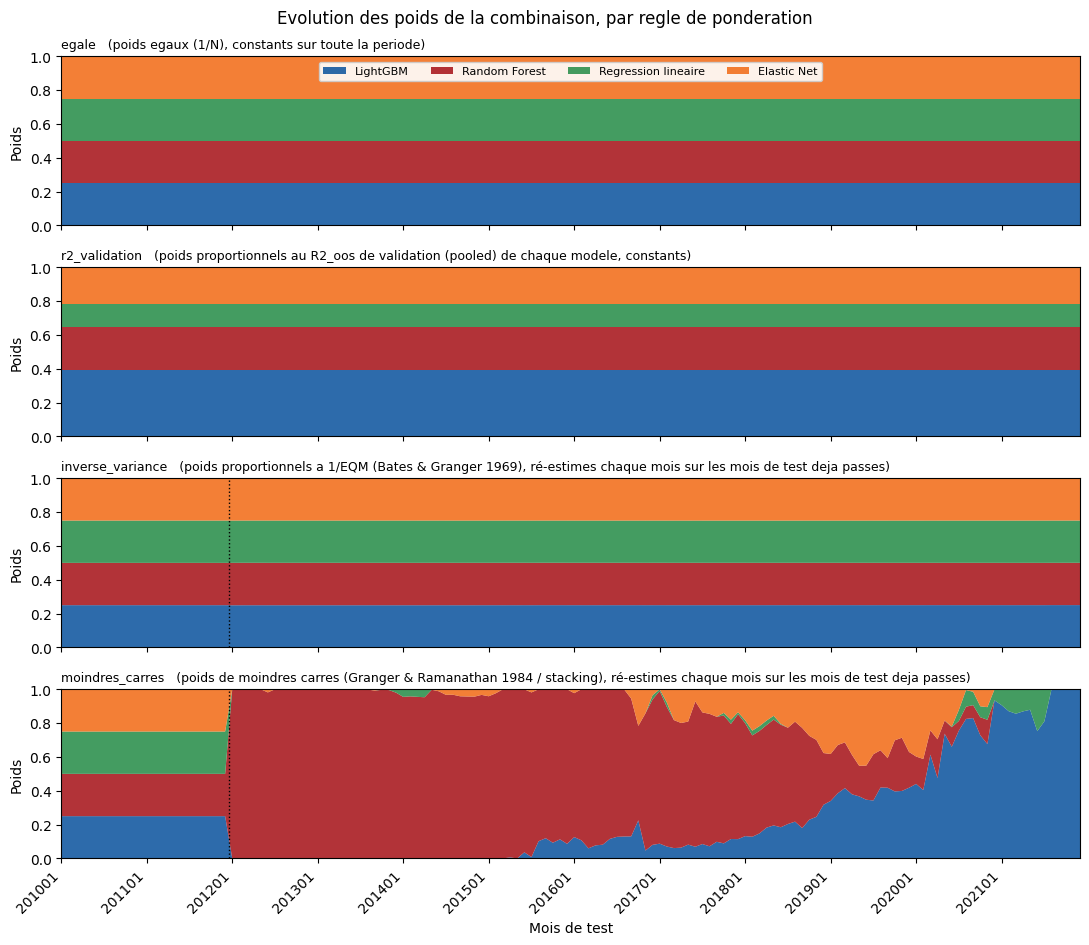

In [24]:
# Une couleur PAR MODELE, identique dans les 4 panneaux : c'est ce qui permet de comparer
# les panneaux entre eux. La palette s'etend automatiquement si tu ajoutes des modeles.
PALETTE_MODELES = ['#08519c', '#a50f15', '#238b45', '#f16913', '#6a51a3', '#8c6d31']
COULEURS_MODELES = {m: PALETTE_MODELES[i % len(PALETTE_MODELES)]
                    for i, m in enumerate(modeles_ensemble)}

HAUTEUR_PAR_PANNEAU = 2.4          # ajuste ces deux constantes a la main
LARGEUR_FIGURE = 11.0
TAILLE_FIGURE = (LARGEUR_FIGURE, HAUTEUR_PAR_PANNEAU * len(methodes_ensemble))

fig, axes = plt.subplots(len(methodes_ensemble), 1, sharex=True, figsize=TAILLE_FIGURE)
axes = np.atleast_1d(axes)

mois = comparaison_ensembles['poids'][methodes_ensemble[0]].index
x = np.arange(len(mois))

for ax, methode in zip(axes, methodes_ensemble):
    tableau = comparaison_ensembles['poids'][methode]
    ax.stackplot(x, *[tableau[m].values for m in modeles_ensemble],
                 labels=modeles_ensemble,
                 colors=[COULEURS_MODELES[m] for m in modeles_ensemble], alpha=0.85)
    ax.set_xlim(0, len(mois) - 1)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Poids")
    ax.set_title(f"{methode}   ({ensemble.description(methode)})", fontsize=9, loc='left')

    # Les methodes glissantes retombent sur des poids EGAUX tant que l'historique est trop
    # court : avant ce trait, elles sont identiques a 'egale' par construction, pas par
    # coincidence. Sans ce repere le lecteur croit a un bug.
    n_egaux = int(comparaison_ensembles['diagnostics'].loc[
        methode, 'n_mois_poids_egaux_faute_historique'])
    if n_egaux > 0:
        ax.axvline(n_egaux - 0.5, color='black', linewidth=1.0, linestyle=':')

positions_x = range(0, len(mois), max(len(mois) // 12, 1))
axes[-1].set_xticks(list(positions_x))
axes[-1].set_xticklabels([mois[i] for i in positions_x], rotation=45, ha='right')
axes[-1].set_xlabel("Mois de test")
axes[0].legend(loc='upper center', ncol=len(modeles_ensemble),
               fontsize=8, framealpha=0.9)
fig.suptitle("Evolution des poids de la combinaison, par regle de ponderation",
             fontsize=12)
plt.tight_layout()
plt.savefig(config.FICHIER_ENSEMBLES_POIDS_PNG, dpi=150)
plt.show()

### C.3 Les modèles combinés sont-ils vraiment complémentaires ?

La condition pour que la combinaison apporte quelque chose n'est pas que les modèles soient
bons, mais qu'ils se trompent **différemment**. C'est donc la corrélation de leurs **erreurs**
qu'il faut regarder, pas celle de leurs prédictions :

- **Corrélation des erreurs proche de 1** → les modèles se trompent au même moment sur les
  mêmes titres. Les combiner n'apportera presque rien.
- **Corrélation nettement inférieure à 1** → il y a de la diversification à récupérer, et
  c'est exactement ce que la combinaison exploite.

In [25]:
# ⚠️ C'est la correlation des ERREURS qui decide du gain de la combinaison, pas celle des
# predictions : deux modeles peuvent avoir des predictions tres correlees (ils classent les
# titres dans le meme ordre) tout en se trompant a des moments differents. C'est le second
# cas qui laisse de la place a la diversification.
erreurs = pd.DataFrame({
    m: predictions[cible] - predictions[colonnes_par_modele[m]] for m in modeles_ensemble
})
correlation_erreurs = erreurs.corr()

# Les k(k-1)/2 coefficients hors diagonale, sans passer par un masque + stack (dont le
# dropna implicite declenche un FutureWarning sur les pandas recents).
triangle = np.triu_indices(len(modeles_ensemble), k=1)
correlations_hors_diagonale = correlation_erreurs.to_numpy()[triangle]

if len(modeles_ensemble) == 2:
    # Avec 2 modeles la "matrice" se reduit a un seul coefficient : une phrase est plus
    # lisible qu'un tableau 2x2 dont trois cases sur quatre sont connues d'avance.
    a, b = modeles_ensemble
    print(f"Correlation des erreurs entre {a} et {b} : "
          f"{correlations_hors_diagonale[0]:.3f}")
else:
    print("Correlation des ERREURS entre modeles combines :")
    display(correlation_erreurs.round(3))
    print(f"Moyenne hors diagonale : {correlations_hors_diagonale.mean():.3f}   "
          f"(min {correlations_hors_diagonale.min():.3f}, "
          f"max {correlations_hors_diagonale.max():.3f})")

if correlations_hors_diagonale.max() > 0.95:
    print("-> Tres elevee : ces modeles font quasiment les memes erreurs, le gain de la")
    print("   combinaison sera marginal quelle que soit la regle de ponderation.")

Correlation des ERREURS entre modeles combines :


,LightGBM,Random Forest,Regression lineaire,Elastic Net
LightGBM,1.000,0.999,0.998,0.999
Random Forest,0.999,1.000,0.999,0.999
Regression lineaire,0.998,0.999,1.000,0.999
Elastic Net,0.999,0.999,0.999,1.000


Moyenne hors diagonale : 0.999   (min 0.998, max 0.999)
-> Tres elevee : ces modeles font quasiment les memes erreurs, le gain de la
   combinaison sera marginal quelle que soit la regle de ponderation.


### C.4 Prédiction combinée et R²_oos

La prédiction combinée de chaque ligne est la somme des prédictions des modèles, pondérée par
les poids **du mois de cette ligne**. Son `R²_oos` se calcule exactement comme celui des
modèles individuels (même métrique, mêmes lignes) : les chiffres sont directement comparables
à ceux de la partie A.

In [26]:
r2_composants = comparaison_ensembles['r2_oos_composants']
meilleur_composant = float(r2_composants.max())

comparaison_r2 = pd.DataFrame({
    'r2_oos_test': pd.concat([
        r2_composants.rename(index=lambda m: f"(composant) {m}"),
        comparaison_ensembles['r2_oos'].rename(index=lambda m: f"Ensemble — {m}"),
    ])
})
comparaison_r2['ecart_vs_meilleur_composant'] = (
    comparaison_r2['r2_oos_test'] - meilleur_composant)

print("R2_oos test — memes lignes pour tous, donc directement comparables :")
comparaison_r2.round(5)

R2_oos test — memes lignes pour tous, donc directement comparables :


,r2_oos_test,ecart_vs_meilleur_composant
(composant) LightGBM,0.00480,-0.00009
(composant) Random Forest,0.00489,0.00000
(composant) Regression lineaire,0.00269,-0.00219
(composant) Elastic Net,0.00390,-0.00099
Ensemble — egale,0.00491,0.00003
Ensemble — r2_validation,0.00512,0.00024
Ensemble — inverse_variance,0.00491,0.00003
Ensemble — moindres_carres,0.00564,0.00076


### C.5 Portefeuille long-short de l'ensemble

Exactement la même construction qu'en partie B (déciles mois par mois, achat du décile
`NB_DECILES`, vente à découvert du décile 1, équipondéré) — appliquée cette fois à la
prédiction combinée. Les mesures obtenues sont donc directement comparables à celles des
modèles individuels.

ℹ️ Le niveau des poids n'a aucune importance pour le classement en déciles (multiplier toutes
les prédictions d'un mois par une constante ne change pas leur ordre) : ce sont les poids
**relatifs** entre modèles qui font le travail.

In [27]:
performance_ensembles = comparaison_ensembles['performance']

colonnes_affichees = ['rendement_annualise', 'volatilite_annualisee', 'sharpe_ratio',
                      'max_drawdown', 't_stat']
print("Portefeuille long-short de la combinaison, par regle de ponderation :")
performance_ensembles[colonnes_affichees].round(4)

Portefeuille long-short de la combinaison, par regle de ponderation :


,rendement_annualise,volatilite_annualisee,sharpe_ratio,max_drawdown,t_stat
egale,0.1769,0.1331,1.3289,-0.1409,4.6035
r2_validation,0.1740,0.1372,1.2686,-0.1495,4.3944
inverse_variance,0.1772,0.1332,1.3301,-0.1393,4.6077
moindres_carres,0.1654,0.1406,1.1763,-0.2063,4.0749


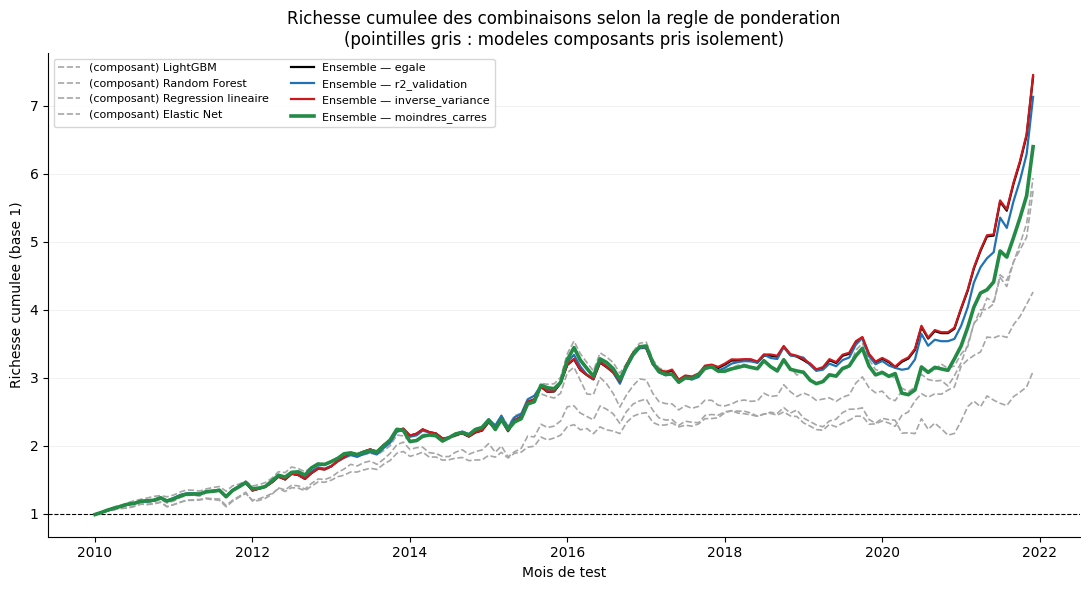

In [28]:
PALETTE_METHODES = ['#000000', '#2171b5', '#cb181d', '#238b45', '#6a51a3']
COULEURS_METHODES = {m: PALETTE_METHODES[i % len(PALETTE_METHODES)]
                     for i, m in enumerate(methodes_ensemble)}

TAILLE_FIGURE = (11, 6)

# ⚠️ La cause des traits parasites : `annee_mois` est une CHAINE ('201001'), donc matplotlib
# la traite comme une categorie et pose un tick par mois. En vraies dates, il choisit tout
# seul des graduations annuelles espacees.
def en_dates(serie):
    return pd.to_datetime(serie.index.astype(str), format='%Y%m')

fig, ax = plt.subplots(figsize=TAILLE_FIGURE)

for modele in modeles_ensemble:
    richesse = (1 + rendements_portefeuilles[modele]).cumprod()
    ax.plot(en_dates(richesse), richesse.values, color='0.65', linewidth=1.2,
            linestyle='--', zorder=1, label=f"(composant) {modele}")

for methode in methodes_ensemble:
    richesse = (1 + comparaison_ensembles['rendements'][methode]).cumprod()
    reference = (methode == config.METHODE_PONDERATION_ENSEMBLE)
    ax.plot(en_dates(richesse), richesse.values, label=f"Ensemble — {methode}",
            color=COULEURS_METHODES[methode],
            linewidth=2.6 if reference else 1.6, zorder=5 if reference else 3)

ax.axhline(1, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel("Richesse cumulee (base 1)")
ax.set_xlabel("Mois de test")
ax.set_title("Richesse cumulee des combinaisons selon la regle de ponderation\n"
             "(pointilles gris : modeles composants pris isolement)", fontsize=12)
ax.legend(fontsize=8, ncol=2)

# Grille horizontale uniquement, discrete : les verticales n'apportent rien sur une serie
# temporelle et c'est elles qui saturaient la figure.
ax.grid(axis='y', alpha=0.2, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(config.FICHIER_ENSEMBLES_CUMULATIF_PNG, dpi=150)
plt.show()

### C.6 Sauvegarde et enregistrement de l'expérience

Le portefeuille combiné est traité **comme un modèle à part entière** : il obtient sa propre
`cle_experience`, sa ligne au journal des expériences et ses mesures dans l'historique
cumulatif des portefeuilles. Il apparaîtra donc dans les tableaux du notebook 09, à côté des
quatre modèles individuels.

⚠️ Sa clé d'expérience inclut les `cle_experience` des modèles **sources** : combiner un
LightGBM entraîné avec la grille A ou avec la grille B donne deux ensembles différents, donc
deux lignes distinctes — et jamais un doublon si rien n'a changé.

ℹ️ Les colonnes `r2_oos_train` et `r2_oos_validation` du journal valent `NaN` pour cette ligne,
et c'est normal : l'ensemble n'a **pas** de phase d'entraînement propre. Il ne combine que des
prédictions de **test** déjà sauvegardées — sa durée d'entraînement est donc nulle, elle aussi.

In [29]:
METHODE_REFERENCE = config.METHODE_PONDERATION_ENSEMBLE
nom_ensemble = config.NOM_MODELE_ENSEMBLE

# --- Fichiers de SENSIBILITE (les 4 methodes), separes du reste ---
pd.concat(comparaison_ensembles['poids'], names=['methode', 'annee_mois']).to_parquet(
    config.FICHIER_POIDS_ENSEMBLE_METHODES)
comparaison_ensembles['performance'].to_parquet(
    config.FICHIER_PERFORMANCE_ENSEMBLES_METHODES)

# --- Ligne de REFERENCE : une seule methode alimente le journal et le notebook 09 ---
r2_ensemble = float(comparaison_ensembles['r2_oos'][METHODE_REFERENCE])
rendements_portefeuilles[nom_ensemble] = comparaison_ensembles['rendements'][METHODE_REFERENCE]
performance.loc[nom_ensemble] = comparaison_ensembles['performance'].loc[METHODE_REFERENCE]
performance = performance.sort_values('sharpe_ratio', ascending=False)

cles_composantes = [resultats.set_index('modele').loc[m, 'cle_experience']
                    for m in modeles_ensemble]
params_ensemble = ensemble.params_specifiques(modeles_ensemble, cles_composantes)
cle_ensemble_experience = journal.cle_experience_actuelle(nom_ensemble, params_ensemble)
performance.loc[nom_ensemble, 'cle_experience'] = cle_ensemble_experience

predictions['pred_ensemble'] = comparaison_ensembles['predictions_combinees'][METHODE_REFERENCE]
predictions[['permno', 'annee_mois', cible, 'pred_ensemble']].rename(
    columns={'pred_ensemble': 'prediction'}
).to_parquet(config.FICHIER_PREDICTIONS_ENSEMBLE, index=False)

rendements_portefeuilles.to_parquet(config.FICHIER_RENDEMENTS_PORTEFEUILLES)
performance.to_parquet(config.FICHIER_PERFORMANCE_PORTEFEUILLES)

journal.enregistrer_experience(
    modele=nom_ensemble,
    params_specifiques=params_ensemble,
    resultats={
        'n_fenetres': int(resultats['n_fenetres'].max()),
        'r2_oos_train': np.nan,        # l'ensemble n'a pas de phase d'entrainement propre
        'r2_oos_validation': np.nan,
        'r2_oos_test': r2_ensemble,
    },
    duree_entrainement_secondes=0.0,
)
journal.enregistrer_performances_portefeuilles(performance)

Experience deja presente dans le journal (cle a7ddbd00634123d7) -- rien ajoute (meme modele, memes parametres generaux et specifiques qu'un lancement precedent).
Historique des performances de portefeuille : rien de nouveau (toutes les experiences de ce lancement y figurent deja).


[]

**Résumé de la partie C :** prédictions de plusieurs modèles combinées en une seule, avec
des poids fixés à la main ou estimés (toujours sur le **passé** uniquement), puis traduites en
portefeuille long-short évalué comme les autres. Poids sauvegardés dans
`outputs/poids_ensemble_par_mois.parquet`, prédictions combinées dans
`outputs/predictions_ensemble.parquet`.

**Pour explorer**, dans `config.py` : change `MODELES_ENSEMBLE` (quels modèles),
`METHODE_PONDERATION_ENSEMBLE` (comment les pondérer), `FENETRE_PONDERATION_ENSEMBLE_MOIS`
(sur quelle profondeur d'historique), puis ré-exécute ce notebook — chaque configuration
devient une expérience distincte au notebook 09, sans écraser les précédentes.

⚠️ **Limites propres à cette partie**, en plus de celles de la partie B :
- Les poids sont estimés sur des **mois de test passés**. Réaliste (aucune information future
  n'est utilisée), mais ça suppose implicitement qu'on aurait, à l'époque, déjà disposé des
  quatre modèles entraînés — la combinaison est donc réalisable *au sein de ce protocole*,
  pas forcément « en temps réel » au sens strict.
- Combiner des modèles entraînés sur les **mêmes** données et les **mêmes** prédicteurs limite
  mécaniquement la diversification atteignable (voir les corrélations d'erreurs en C.3).
- Multiplier les configurations d'ensemble jusqu'à en trouver une qui bat tout le monde est
  une forme de *data snooping* : le notebook 09 garde la trace de **toutes** celles testées,
  précisément pour que ce nombre reste visible.

## Partie D — Évaluation factorielle : FF5 + momentum

Les parties B et C mesurent la performance **en niveau** : combien rapporte le portefeuille,
avec quelle volatilité, contre deux repères long only. Ce qui manque, c'est la question qu'un
jury en finance quantitative posera en premier : ce rendement est-il **autre chose** que ce
qu'un investisseur obtiendrait déjà en achetant des facteurs connus depuis vingt ans ?

La question n'a rien de rhétorique ici. Les déciles sont triés sur des caractéristiques dont
plusieurs — `mvel1`, `bm`, `mom12m`, `operprof`, `agr` — sont précisément les briques
utilisées pour construire SMB, HML, RMW, CMA et MOM. Un portefeuille long-short bâti sur ces
variables **doit** charger sur ces facteurs ; toute la question est de savoir ce qu'il reste
une fois cette exposition retirée.

Deux mesures, à ne surtout pas confondre :

| | Question posée | Réponse |
|---|---|---|
| **Alpha** | Le portefeuille rapporte-t-il ce que les facteurs n'expliquent **pas** ? | `α` de $r_{LS,t} = α + β' F_t + ε_t$ |
| **Comparaison** | Le portefeuille fait-il **mieux** qu'un portefeuille de facteurs ? | Sharpe contre Sharpe |

Un alpha positif significatif accompagné d'un Sharpe **inférieur** à celui du momentum seul
n'est pas une contradiction : le premier parle de rendement orthogonal, le second de rendement
total. Les deux méritent leur place dans le mémoire.

⚠️ **Pré-requis** : `python scripts/nettoyage_donnees.py` relancé après l'ajout de la partie D
(c'est elle qui écrit `data/interim/facteurs_clean.parquet`), avec les deux CSV de Ken French
déposés dans `data/raw/`.

⚠️ **Rien de ce qui suit n'alimente le journal des expériences.** Aucune prédiction nouvelle
n'est produite, donc aucune clé d'expérience ne change. Ajouter des colonnes d'alpha à
`journal.COLONNES_PORTEFEUILLE` rendrait par ailleurs l'historique déjà écrit
inconcaténable avec les lignes futures. Même traitement que `performance_constructions.parquet`.

### D.0 Panneau de contrôle

Tous les paramètres de la partie D, au même endroit. Les valeurs par défaut viennent de
`config.py` — pour que le mémoire puisse citer un fichier de paramètres plutôt qu'une cellule
de notebook — mais chacune s'écrase ici, ce qui permet de rejouer la section entière en
changeant une ligne. Rien de ce qui suit ne contient de constante en dur.

In [30]:
# --- Constructions evaluees --------------------------------------------------------
D_PONDERATIONS = list(config.PONDERATIONS_EVALUEES)   # 'equipondere' et/ou 'capitalisation'

# --- Couts, DIFFERENCIES par schema de ponderation ---------------------------------
# ⚠️ Le meme chiffre pour les deux sous-estimerait le handicap de l'equipondere : les couts
# effectifs varient d'un ordre de grandeur entre grandes et petites capitalisations
# (Novy-Marx & Velikov 2016), et l'equipondere met autant d'argent sur le plus petit titre de
# l'univers que sur le plus gros.
D_COUT_TRANSACTION_BPS = dict(config.COUT_TRANSACTION_BPS)   # unidirectionnel, points de base
D_COUT_EMPRUNT_ANNUEL_BPS = config.COUT_EMPRUNT_ANNUEL_BPS   # loyer annuel de la jambe vendeuse

# --- Turnover ----------------------------------------------------------------------
D_TAMPON_DECILES = config.TAMPON_DECILES              # 0 = parties B et C a l'identique
D_IGNORER_PREMIER_MOIS = config.IGNORER_PREMIER_MOIS_TURNOVER

# --- Sensibilite et seuils ---------------------------------------------------------
D_GRILLE_COUTS_BPS = list(config.GRILLE_COUTS_BPS)
D_SEUIL_T = config.SEUIL_T_RENTABILITE

# --- Facteurs ----------------------------------------------------------------------
D_LAGS_NEWEY_WEST = config.LAGS_NEWEY_WEST_ALPHA
D_MODELE_FACTORIEL = config.MODELE_FACTORIEL_REFERENCE

print("Ponderations evaluees      :", ", ".join(D_PONDERATIONS))
print("Cout de transaction (bps)  :", ", ".join(
    f"{p} = {D_COUT_TRANSACTION_BPS.get(p, 0):.0f}" for p in D_PONDERATIONS))
print(f"Cout d'emprunt (bps/an)    : {D_COUT_EMPRUNT_ANNUEL_BPS:.0f} sur la jambe vendeuse")
print(f"Zone tampon                : {D_TAMPON_DECILES} decile(s)"
      f"{'  (aucune -- construction des parties B et C)' if not D_TAMPON_DECILES else ''}")
print(f"Premier mois               : {'ecarte' if D_IGNORER_PREMIER_MOIS else 'inclus'} "
      "du calcul de turnover")
print(f"Grille de sensibilite      : {D_GRILLE_COUTS_BPS} bps")

Ponderations evaluees      : equipondere, capitalisation
Cout de transaction (bps)  : equipondere = 40, capitalisation = 15
Cout d'emprunt (bps/an)    : 30 sur la jambe vendeuse
Zone tampon                : 0 decile(s)  (aucune -- construction des parties B et C)
Premier mois               : ecarte du calcul de turnover
Grille de sensibilite      : [0, 5, 10, 20, 30, 50, 75, 100, 150, 200] bps


### D.1 Chargement des facteurs et des séries à évaluer

Les séries long-short existent déjà : `rendements_portefeuilles` les contient toutes, une
colonne par modèle, plus celle de l'ensemble ajoutée en C.6. Rien n'est recalculé ici.

In [31]:
fact = facteurs.charger_facteurs(config.FICHIER_FACTEURS_CLEAN)

# --- Les series long-short de la partie B, INCHANGEES -----------------------------
# ⚠️ D.2, D.3 et D.4 travaillent sur ces series-la, exactement comme avant l'ajout des
# couts : `rendements_portefeuilles` sort de la partie B et n'est pas retouche ici. C'est
# ce qui garantit que mettre les couts a zero redonne strictement les memes alphas et le
# meme tableau de comparaison qu'avant. Les series recalculees a partir des poids (D.1bis)
# servent uniquement aux sections D.5 a D.8.
series_ls = {nom: rendements_portefeuilles[nom].rename(None)
             for nom in rendements_portefeuilles.columns}
for nom, serie in series_ls.items():
    serie.index = serie.index.astype(str)

print("Series long-short a evaluer :")
for nom, serie in series_ls.items():
    valides = serie.dropna()
    couverture = len(set(valides.index) & set(fact.index))
    print(f"  {nom:22s} : {len(valides):3d} mois ({valides.index.min()}-{valides.index.max()}), "
          f"dont {couverture} couverts par les facteurs")

manquants = sorted(set(rendements_portefeuilles.index.astype(str)) - set(fact.index))
if manquants:
    print(f"\n⚠️ {len(manquants)} mois de test sans facteurs : {manquants[:6]}"
          f"{' ...' if len(manquants) > 6 else ''}")
    print("   Ils seront ecartes de TOUTES les lignes des tableaux, modeles comme facteurs.")
print()

# --- Appoint du panel, pour les sections D.5 a D.8 --------------------------------
# La capitalisation et le rendement TOTAL vivent dans le PANEL, pas dans les fichiers de
# predictions. ⚠️ `mvel1_brut` et non `mvel1` : ce dernier vit dans [-1, 1] apres rank
# transform et ne serait pas un poids valide. ⚠️ `RET` et non `excess_return` pour la derive
# des poids : la valeur de marche d'une position croit au rendement TOTAL, et retrancher le
# taux sans risque introduirait un biais faible mais systematique.
COLONNE_CAPI = config.COLONNE_MVEL1_BRUT

colonnes_panel = ['permno', 'annee_mois', COLONNE_CAPI, 'RET']
panel_appoint = pd.read_parquet(config.FICHIER_PANEL_MODELISATION, columns=colonnes_panel)
panel_appoint['annee_mois'] = panel_appoint['annee_mois'].astype(str)

predictions_d = predictions.copy()
predictions_d['annee_mois'] = predictions_d['annee_mois'].astype(str)

# ⚠️ Si ces colonnes sont deja presentes (notebook rejoue sans redemarrer le noyau), le merge
# fabriquerait `mvel1_brut_x` / `mvel1_brut_y` et la suite echouerait sur un KeyError peu
# parlant. On les retire d'abord : la version du panel fait foi.
deja_presentes = [c for c in (COLONNE_CAPI, 'RET') if c in predictions_d.columns]
if deja_presentes:
    predictions_d = predictions_d.drop(columns=deja_presentes)

predictions_d = predictions_d.merge(panel_appoint, on=['permno', 'annee_mois'], how='left')

pct_capi_manquante = float(predictions_d[COLONNE_CAPI].isna().mean() * 100)
pct_ret_manquant = float(predictions_d['RET'].isna().mean() * 100)
print(f"Capitalisation renseignee : {100 - pct_capi_manquante:.1f} % des lignes")
print(f"Rendement total renseigne : {100 - pct_ret_manquant:.1f} % des lignes")
if pct_capi_manquante > 5:
    print(f"⚠️ {pct_capi_manquante:.1f} % de capitalisations manquantes. Les portefeuilles")
    print("   ponderes ecartent ces lignes : leur univers n'est donc pas rigoureusement")
    print("   celui des equiponderes, et l'ecart de performance melange alors deux effets.")

# Le decile de l'ensemble n'existe pas encore : la partie C n'a produit que ses rendements.
if 'decile_ensemble' not in predictions_d.columns:
    predictions_d['decile_ensemble'] = portefeuilles.assigner_deciles_par_mois(
        predictions_d, 'pred_ensemble', n=NB_DECILES)

colonnes_decile = {nom: f'decile_{cle}' for nom, (cle, _) in fichiers_predictions.items()}
colonnes_decile[config.NOM_MODELE_ENSEMBLE] = 'decile_ensemble'

# Table (mois x titre) des rendements, pour la derive des poids.
rendements_titres = couts.rendements_titres_par_mois(
    predictions_d.dropna(subset=['RET']), 'RET')

POIDS_PAR_PONDERATION = {'equipondere': None, 'capitalisation': COLONNE_CAPI}

print()
print(f"{len(colonnes_decile)} modeles x {len(D_PONDERATIONS)} ponderations a evaluer, "
      f"sur {predictions_d['annee_mois'].nunique()} mois.")

Series long-short a evaluer :
  Regression lineaire    : 144 mois (201001-202112), dont 144 couverts par les facteurs
  Elastic Net            : 144 mois (201001-202112), dont 144 couverts par les facteurs
  LightGBM               : 144 mois (201001-202112), dont 144 couverts par les facteurs
  Random Forest          : 144 mois (201001-202112), dont 144 couverts par les facteurs
  Ensemble               : 144 mois (201001-202112), dont 144 couverts par les facteurs

Capitalisation renseignee : 100.0 % des lignes
Rendement total renseigne : 100.0 % des lignes

5 modeles x 2 ponderations a evaluer, sur 144 mois.


In [32]:
# Une passe unique : poids, turnover, rendement brut, couts, rendement net.
# ⚠️ C'est l'etape lourde de la partie D (une table mois x titre par jambe). Comptez une a
# deux minutes ; tout le reste de la section relit ces resultats sans recalculer.
resultats_couts = {}

for ponderation in D_PONDERATIONS:
    colonne_poids = POIDS_PAR_PONDERATION[ponderation]
    cout_bps = D_COUT_TRANSACTION_BPS.get(ponderation, 0.0)

    for nom_modele, colonne_decile in colonnes_decile.items():
        resultats_couts[(nom_modele, ponderation)] = couts.evaluer_long_short(
            predictions_d, colonne_decile, rendements_titres,
            nb_deciles=NB_DECILES,
            colonne_poids=colonne_poids,
            tampon_deciles=D_TAMPON_DECILES,
            cout_transaction_bps=cout_bps,
            cout_emprunt_annuel_bps=D_COUT_EMPRUNT_ANNUEL_BPS,
            ignorer_premier_mois=D_IGNORER_PREMIER_MOIS,
        )
    print(f"  {ponderation:16s} : {len(colonnes_decile)} modeles evalues "
          f"(cout {cout_bps:.0f} bps)")

# --- Controle de coherence avec la partie B ---------------------------------------
# Sans zone tampon et en equipondere, le rendement brut recalcule ici DOIT coincider avec
# `rendements_portefeuilles`. Un ecart ne serait pas anodin : il signalerait que les deux
# constructions ne portent pas sur le meme univers.
if 'equipondere' in D_PONDERATIONS and not D_TAMPON_DECILES:
    print()
    print("Controle : ecart maximal avec les rendements de la partie B (doit etre ~0) :")
    for nom_modele in colonnes_decile:
        brut = resultats_couts[(nom_modele, 'equipondere')]['rendement_brut']
        reference = rendements_portefeuilles[nom_modele]
        reference.index = reference.index.astype(str)
        ecart = (brut - reference.reindex(brut.index)).abs().max()
        drapeau = "" if ecart < 1e-9 else "   ⚠️ univers non identique"
        print(f"  {nom_modele:22s} : {ecart:.2e}{drapeau}")

  equipondere      : 5 modeles evalues (cout 40 bps)
  capitalisation   : 5 modeles evalues (cout 15 bps)

Controle : ecart maximal avec les rendements de la partie B (doit etre ~0) :
  Regression lineaire    : 1.80e-16
  Elastic Net            : 3.33e-16
  LightGBM               : 3.05e-16
  Random Forest          : 3.89e-16
  Ensemble               : 3.33e-16


### D.2 Les alphas — ce que les facteurs n'expliquent pas

Quatre modèles factoriels **emboîtés**, du plus simple au plus complet. Le tableau se lit de
gauche à droite : chaque colonne montre ce qu'il reste d'alpha une fois un bloc de facteurs
supplémentaire retiré. L'écart entre les colonnes `FF5` et `FF5+MOM` chiffre la part de la
performance qui n'est, au fond, que du momentum reconditionné — chiffre à rapprocher de
l'importance des variables `mom1m` et `mom12m` observée aux notebooks 06 et 07.

Les écarts-types sont ceux de Newey-West (`config.LAGS_NEWEY_WEST_ALPHA` retards, 3 par
défaut). ⚠️ Cette valeur vaut pour l'horizon 1 mois, où les rendements ne se chevauchent pas.
Le notebook 11 doit passer `facteurs.lags_par_defaut(config.HORIZON_PREDICTION_MOIS)`, soit 11
retards : les cohortes de Jegadeesh-Titman y partagent onze douzièmes de leurs positions d'un
mois sur l'autre, et l'ignorer gonflerait mécaniquement la significativité de l'alpha.

In [33]:
alphas = facteurs.alphas_par_portefeuille(
    series_ls, fact, lags_newey_west=config.LAGS_NEWEY_WEST_ALPHA)
alphas.to_parquet(config.FICHIER_ALPHAS_PORTEFEUILLES, index=False)

ordre_modeles = list(series_ls)
ordre_factoriel = list(facteurs.MODELES_FACTORIELS)

print("Alpha ANNUALISE (%), par modele factoriel — de gauche a droite, du plus simple au plus complet :")
display(alphas.pivot(index='modele', columns='modele_factoriel', values='alpha_annualise')
        .reindex(index=ordre_modeles, columns=ordre_factoriel).mul(100).round(2))

print("t-stat de l'alpha (Newey-West) — |t| > 1.96 : significatif a 5 % :")
display(alphas.pivot(index='modele', columns='modele_factoriel', values='alpha_t_stat')
        .reindex(index=ordre_modeles, columns=ordre_factoriel).round(2))

# ⚠️ Indexation directe plutot que `.eval()` : le nom de colonne 'FF5+MOM' contient un '+',
# que la syntaxe d'expression de pandas n'accepte qu'avec des backticks, et dont le support
# depend de la version installee. Deux crochets ne dependent d'aucune version.
alphas_par_bloc = alphas.pivot(index='modele', columns='modele_factoriel',
                               values='alpha_annualise').reindex(ordre_modeles)
cout_momentum = (alphas_par_bloc['FF5'] - alphas_par_bloc['FF5+MOM']) * 100
print("Alpha absorbe par le SEUL ajout de MOM (points de pourcentage annualises) :")
display(cout_momentum.round(2))

Alpha ANNUALISE (%), par modele factoriel — de gauche a droite, du plus simple au plus complet :


modele_factoriel,CAPM,FF3,FF5,FF5+MOM
modele,,,,
Regression lineaire,12.76,14.05,12.07,10.17
Elastic Net,13.02,14.15,12.30,9.37
LightGBM,16.01,17.10,13.44,11.74
Random Forest,17.82,19.48,15.79,13.80
Ensemble,18.57,19.59,16.13,14.02


t-stat de l'alpha (Newey-West) — |t| > 1.96 : significatif a 5 % :


modele_factoriel,CAPM,FF3,FF5,FF5+MOM
modele,,,,
Regression lineaire,4.01,4.76,4.24,4.10
Elastic Net,3.35,3.85,3.39,2.94
LightGBM,3.86,4.37,3.85,3.60
Random Forest,3.94,4.94,4.36,4.39
Ensemble,4.24,4.86,4.24,4.13


Alpha absorbe par le SEUL ajout de MOM (points de pourcentage annualises) :


modele
Regression lineaire    1.91
Elastic Net            2.93
LightGBM               1.70
Random Forest          1.98
Ensemble               2.11
dtype: float64

In [34]:
# Le tableau detaille du modele de reference : alpha, t-stat, les six betas, R2 et ratio
# d'information. C'est celui qui part en LaTeX.
tableau_alphas = facteurs.tableau_alphas_latex(
    alphas, modele_factoriel=config.MODELE_FACTORIEL_REFERENCE)

print(f"Regression sur {config.MODELE_FACTORIEL_REFERENCE} — alpha en % annualise :")
print("ℹ️ `ratio_information` = alpha / volatilite du residu. C'est le \"Sharpe de l'alpha\" :")
print("   contrairement a l'alpha brut, il se compare d'un modele a l'autre meme quand les")
print("   portefeuilles n'ont pas la meme volatilite.")
tableau_alphas.round(3)

Regression sur FF5+MOM — alpha en % annualise :
ℹ️ `ratio_information` = alpha / volatilite du residu. C'est le "Sharpe de l'alpha" :
   contrairement a l'alpha brut, il se compare d'un modele a l'autre meme quand les
   portefeuilles n'ont pas la meme volatilite.


,modele,alpha_annualise,alpha_t_stat,beta_mktrf,beta_smb,beta_hml,beta_rmw,beta_cma,beta_mom,r2_facteurs,ratio_information,n_mois
0,Regression lineaire,10.167,4.096,0.067,0.189,0.333,0.378,0.382,0.526,0.410,1.246,144
1,Elastic Net,9.372,2.943,-0.028,0.033,0.560,0.341,0.364,0.809,0.513,0.972,144
2,LightGBM,11.736,3.600,0.081,0.119,0.325,0.866,0.512,0.469,0.394,1.138,144
3,Random Forest,13.802,4.394,-0.043,0.074,0.503,0.857,0.535,0.547,0.480,1.360,144
4,Ensemble,14.023,4.131,-0.003,0.038,0.395,0.751,0.563,0.582,0.407,1.268,144


### D.3 La comparaison — mieux que les facteurs eux-mêmes ?

Un tableau unique, où les quatre modèles, l'ensemble, un portefeuille construit à partir des
six facteurs et chaque facteur pris isolément occupent des lignes strictement comparables :
mêmes mois, mêmes mesures.

Le portefeuille de facteurs est **équipondéré** (1/N sur les six séries). Ce choix n'est pas
un détail. Un portefeuille tangent estimé sur l'ensemble de la période choisirait ses poids en
connaissant les rendements réalisés : il écraserait n'importe quel modèle hors échantillon par
pure construction, et la comparaison n'aurait aucun sens. Le 1/N n'estime rien, n'utilise
aucune information future, et se défend par ailleurs très bien sur le plan empirique
(DeMiguel, Garlappi & Uppal, 2009). `config.METHODE_BENCHMARK_FACTORIEL` permet de basculer
sur `'variance_inverse'`, dont les poids sont estimés sur les seuls mois passés.

⚠️ Deux réserves à porter en note de tableau. D'abord, les six facteurs ne sont pas de même
nature : MKT-RF est un rendement excédentaire, les cinq autres sont des spreads autofinancés,
et le 1/N revient donc à détenir le marché à hauteur d'un sixième. Ensuite, les facteurs de
Ken French couvrent l'intégralité de CRSP, microcaps comprises, là où les filtres de taille et
de liquidité de l'étape 03 ont retiré les déciles extrêmes de l'univers — le repère n'est donc
pas exactement investissable dans le périmètre des modèles.

⚠️ La ligne du benchmark n'a pas d'alpha renseigné : combinaison linéaire des facteurs, son
alpha vaut zéro et son résidu est nul à la précision machine près. Les lignes des facteurs
isolés non plus, pour la même raison.

In [35]:
comparaison = facteurs.comparer_aux_facteurs(
    series_ls, fact, portefeuilles.calculer_metriques,
    modele_factoriel=config.MODELE_FACTORIEL_REFERENCE,
    lags_newey_west=config.LAGS_NEWEY_WEST_ALPHA,
    methode_benchmark=config.METHODE_BENCHMARK_FACTORIEL,
    nom_benchmark=config.NOM_BENCHMARK_FACTORIEL,
    fenetre_mois=config.FENETRE_BENCHMARK_FACTORIEL_MOIS,
    mois_minimum=config.MOIS_MINIMUM_BENCHMARK_FACTORIEL,
)
comparaison.to_parquet(config.FICHIER_COMPARAISON_FACTEURS, index=False)

# La serie du benchmark, sauvegardee a part : elle sert a la figure D.4 et au notebook 09.
benchmark_facteurs = facteurs.portefeuille_facteurs(
    fact, methode=config.METHODE_BENCHMARK_FACTORIEL,
    fenetre_mois=config.FENETRE_BENCHMARK_FACTORIEL_MOIS,
    mois_minimum=config.MOIS_MINIMUM_BENCHMARK_FACTORIEL)
benchmark_facteurs.rename('rendement').rename_axis('annee_mois').reset_index().to_parquet(
    config.FICHIER_RENDEMENTS_BENCHMARK_FACTORIEL, index=False)

facteurs.performance_facteurs(fact, portefeuilles.calculer_metriques).to_parquet(
    config.FICHIER_PERFORMANCE_FACTEURS, index=False)

print("Modeles, benchmark factoriel et facteurs isoles — MEMES mois, MEMES mesures.")
print("Rendements, volatilites, drawdowns et alphas en POURCENTAGE annualise.")
display(facteurs.tableau_comparaison_latex(comparaison).round(2))

print("Fichiers sauvegardes :")
print("  ", config.FICHIER_ALPHAS_PORTEFEUILLES)
print("  ", config.FICHIER_COMPARAISON_FACTEURS)
print("  ", config.FICHIER_RENDEMENTS_BENCHMARK_FACTORIEL)
print("  ", config.FICHIER_PERFORMANCE_FACTEURS)

Modeles, benchmark factoriel et facteurs isoles — MEMES mois, MEMES mesures.
Rendements, volatilites, drawdowns et alphas en POURCENTAGE annualise.


,type,portefeuille,rendement_annualise,volatilite_annualisee,sharpe_ratio,max_drawdown,alpha_annualise,alpha_t_stat,ratio_information,n_mois
0,Modele,Regression lineaire,12.68,10.39,1.22,-11.34,10.17,4.10,1.25,144
1,Modele,Elastic Net,10.36,13.53,0.77,-19.75,9.37,2.94,0.97,144
2,Modele,LightGBM,15.76,12.97,1.22,-19.86,11.74,3.60,1.14,144
3,Modele,Random Forest,15.59,13.77,1.13,-20.94,13.80,4.39,1.36,144
4,Modele,Ensemble,16.54,14.06,1.18,-20.63,14.02,4.13,1.27,144
5,Benchmark,FF5+MOM (1/N),2.93,3.83,0.77,-10.23,0.00,NaN,NaN,144
6,Facteur,mktrf,14.86,14.41,1.03,-20.48,NaN,NaN,NaN,144
7,Facteur,smb,0.16,8.87,0.02,-28.58,NaN,NaN,NaN,144
8,Facteur,hml,-3.09,10.04,-0.31,-53.38,NaN,NaN,NaN,144
9,Facteur,rmw,2.85,6.35,0.45,-12.12,NaN,NaN,NaN,144


Fichiers sauvegardes :
   C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\alphas_portefeuilles.parquet
   C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\comparaison_modeles_vs_facteurs.parquet
   C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\rendements_benchmark_factoriel.parquet
   C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\performance_facteurs.parquet


In [36]:
# Lecture directe du tableau : qui bat le benchmark factoriel, en Sharpe ?
sharpe_benchmark = float(
    comparaison.loc[comparaison['portefeuille'] == config.NOM_BENCHMARK_FACTORIEL,
                    'sharpe_ratio'].iloc[0])
modeles_seuls = comparaison[comparaison['type'] == 'Modele']

print(f"Sharpe du benchmark {config.NOM_BENCHMARK_FACTORIEL} : {sharpe_benchmark:+.3f}")
print()
for _, ligne in modeles_seuls.sort_values('sharpe_ratio', ascending=False).iterrows():
    ecart = ligne['sharpe_ratio'] - sharpe_benchmark
    verdict = "au-dessus" if ecart > 0 else "en dessous"
    significatif = "" if pd.isna(ligne['alpha_t_stat']) else (
        " | alpha significatif a 5 %" if abs(ligne['alpha_t_stat']) > 1.96
        else " | alpha NON significatif a 5 %")
    print(f"  {ligne['portefeuille']:22s} : Sharpe {ligne['sharpe_ratio']:+.3f} "
          f"({ecart:+.3f}, {verdict}){significatif}")

print()
print("⚠️ Ces deux verdicts peuvent diverger, et ce n'est pas une incoherence : un alpha")
print("   significatif dit que le portefeuille apporte du rendement ORTHOGONAL aux facteurs,")
print("   un Sharpe inferieur dit qu'il en apporte moins AU TOTAL. Les deux sont vrais.")

Sharpe du benchmark FF5+MOM (1/N) : +0.765

  Regression lineaire    : Sharpe +1.220 (+0.455, au-dessus) | alpha significatif a 5 %
  LightGBM               : Sharpe +1.215 (+0.450, au-dessus) | alpha significatif a 5 %
  Ensemble               : Sharpe +1.176 (+0.411, au-dessus) | alpha significatif a 5 %
  Random Forest          : Sharpe +1.132 (+0.367, au-dessus) | alpha significatif a 5 %
  Elastic Net            : Sharpe +0.766 (+0.000, au-dessus) | alpha significatif a 5 %

⚠️ Ces deux verdicts peuvent diverger, et ce n'est pas une incoherence : un alpha
   significatif dit que le portefeuille apporte du rendement ORTHOGONAL aux facteurs,
   un Sharpe inferieur dit qu'il en apporte moins AU TOTAL. Les deux sont vrais.


### D.4 Richesse cumulée — les modèles contre les facteurs

Échelle logarithmique : sur une décennie, une échelle linéaire écrase visuellement les
premières années et donne l'impression trompeuse que tout se joue à la fin.

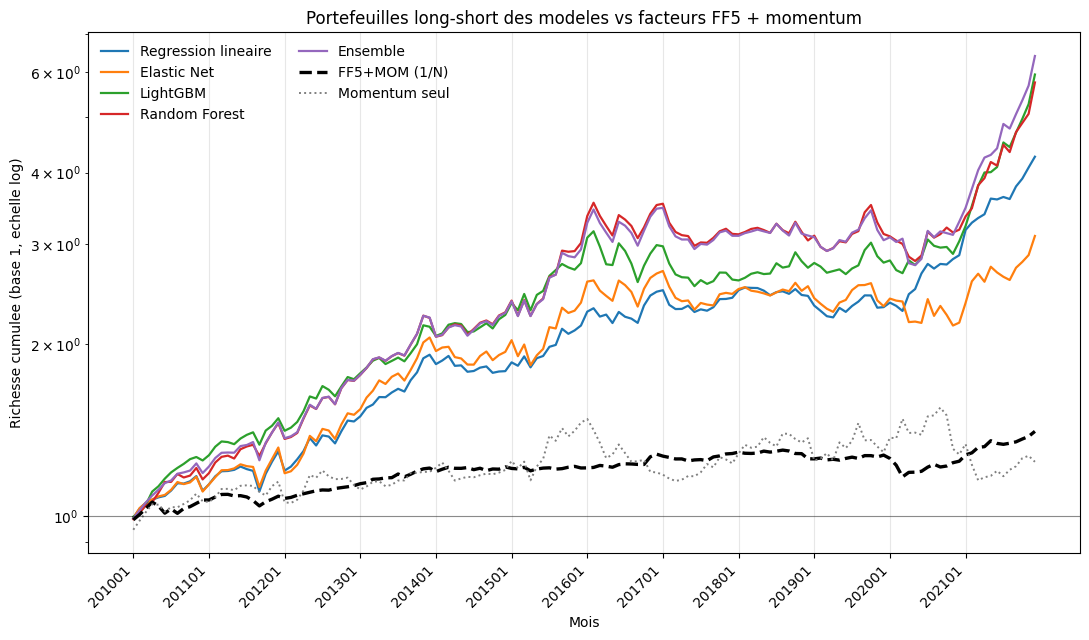

Figure sauvegardee : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\portefeuilles_vs_facteurs_richesse_cumulee.png


In [37]:
mois_communs = benchmark_facteurs.index.intersection(
    next(iter(series_ls.values())).dropna().index)

fig, ax = plt.subplots(figsize=(11, 6.5))

for nom, serie in series_ls.items():
    ax.plot(mois_communs, (1 + serie.reindex(mois_communs).fillna(0)).cumprod(),
            linewidth=1.6, label=nom)

ax.plot(mois_communs, (1 + benchmark_facteurs.reindex(mois_communs).fillna(0)).cumprod(),
        linewidth=2.4, color='black', linestyle='--', label=config.NOM_BENCHMARK_FACTORIEL)

# Le momentum seul : c'est LE concurrent naturel de modeles domines par mom1m / mom12m.
ax.plot(mois_communs, (1 + fact.loc[mois_communs, facteurs.MOM]).cumprod(),
        linewidth=1.4, color='grey', linestyle=':', label='Momentum seul')

ax.set_yscale('log')
ax.set_ylabel("Richesse cumulee (base 1, echelle log)")
ax.set_xlabel("Mois")
ax.set_xticks(list(mois_communs)[::12])
ax.set_xticklabels(list(mois_communs)[::12], rotation=45, ha='right')
ax.axhline(1, color='black', linewidth=0.8, alpha=0.4)
ax.legend(frameon=False, ncol=2)
ax.grid(alpha=0.3)
ax.set_title("Portefeuilles long-short des modeles vs facteurs FF5 + momentum")
fig.tight_layout()
fig.savefig(config.FICHIER_FACTEURS_CUMULATIF_PNG, dpi=150)
plt.show()

print("Figure sauvegardee :", config.FICHIER_FACTEURS_CUMULATIF_PNG)

### D.5 Turnover — combien la stratégie fait-elle tourner son portefeuille ?

Le principe tient en une phrase : **détenir ne coûte rien, seule la différence entre ce qu'on
veut et ce qu'on a déjà coûte quelque chose.**

Vous formez un portefeuille fin *t* avec des poids $w_{i,t}$. Pendant *t+1* vous ne passez
aucun ordre, mais les poids bougent seuls — les titres qui montent prennent une part plus
grande. Vos poids effectifs deviennent

$$w^{+}_{i,t} = \frac{w_{i,t}(1+r_{i,t+1})}{\sum_j w_{j,t}(1+r_{j,t+1})}$$

Cette dérive est **gratuite**. Le turnover ne compte que ce qu'il faut échanger pour revenir
aux poids voulus :

$$TO_{t+1} = \sum_i \left| w_{i,t+1} - w^{+}_{i,t} \right|$$

Convention **bidirectionnelle** : une jambe intégralement renouvelée donne 1,0 (tout vendre,
tout racheter), et le long-short cumule ses deux jambes. Une partie de la littérature divise
par deux — la note de tableau doit préciser laquelle est retenue, sinon les coûts sont faux
d'un facteur deux.

**La décomposition est le vrai intérêt de ce tableau.** La rotation vient de deux sources
qu'il ne faut pas confondre. Les **entrées-sorties** mesurent le renouvellement de la
composition : c'est la rotation imputable au signal du modèle, à quel point ses classements
bougent. Le **rééquilibrage** concerne les titres présents les deux mois, dont le poids doit
être ramené à sa cible — et cette part n'est pas nulle même à composition rigoureusement
constante, puisqu'un portefeuille équipondéré dérive mécaniquement. Ce plancher tourne autour
de 5 % par mois et n'est imputable à aucun modèle : c'est le prix de l'équipondération
elle-même.

In [38]:
lignes_turnover = []
for (nom_modele, ponderation), resultat in resultats_couts.items():
    decomposition = resultat['decomposition_turnover']
    utiles = decomposition.iloc[1:] if D_IGNORER_PREMIER_MOIS else decomposition

    ligne = {'modele': nom_modele, 'ponderation': ponderation}
    ligne.update(couts.resumer_turnover(utiles['turnover']))
    ligne['part_entrees_sorties'] = float(utiles['entrees_sorties'].mean())
    ligne['part_rebalancement'] = float(utiles['rebalancement'].mean())
    lignes_turnover.append(ligne)

turnover_table = pd.DataFrame(lignes_turnover)
turnover_table.to_parquet(config.FICHIER_TURNOVER_PORTEFEUILLES, index=False)

print("Turnover mensuel (convention bidirectionnelle, les deux jambes cumulees) :")
display(turnover_table.set_index(['ponderation', 'modele'])[
    ['turnover_mensuel_moyen', 'part_entrees_sorties', 'part_rebalancement',
     'duree_detention_mois', 'n_mois']].round(3))

print("ℹ️ `part_entrees_sorties` + `part_rebalancement` = `turnover_mensuel_moyen`.")
print("   La premiere est imputable au SIGNAL du modele, la seconde a la PONDERATION.")
print("   Comparer les modeles entre eux sur la premiere colonne, pas sur le total.")

Turnover mensuel (convention bidirectionnelle, les deux jambes cumulees) :


turnover_mensuel_moyen  part_entrees_sorties  part_rebalancement  \
ponderation    modele                                                                                  
equipondere    Regression lineaire                   2.452                 2.380               0.072   
               Elastic Net                           1.426                 1.301               0.124   
               LightGBM                              2.206                 2.095               0.111   
               Random Forest                         1.847                 1.709               0.138   
               Ensemble                              1.939                 1.817               0.123   
capitalisation Regression lineaire                   2.661                 2.461               0.200   
               Elastic Net                           1.590                 1.362               0.228   
               LightGBM                              2.523                 2.291               0.233   
               Random Forest                         2.228                 1.983               0.245   
               Ensemble                              2.239                 1.995               0.244   

                                    duree_detention_mois  n_mois  
ponderation    modele                                             
equipondere    Regression lineaire                 1.632     143  
               Elastic Net                         2.805     143  
               LightGBM                            1.813     143  
               Random Forest                       2.166     143  
               Ensemble                            2.063     143  
capitalisation Regression lineaire                 1.503     143  
               Elastic Net                         2.516     143  
               LightGBM                            1.585     143  
               Random Forest                       1.796     143  
               Ensemble                            1.786     143

ℹ️ `part_entrees_sorties` + `part_rebalancement` = `turnover_mensuel_moyen`.
   La premiere est imputable au SIGNAL du modele, la seconde a la PONDERATION.
   Comparer les modeles entre eux sur la premiere colonne, pas sur le total.


### D.6 Coûts de transaction et coût d'emprunt

Deux coûts distincts, qui ne se réduisent pas par les mêmes leviers.

| | Déclencheur | Base de calcul | Réduit par |
|---|---|---|---|
| **Transaction** | passer un ordre | turnover du mois | tenir ses positions plus longtemps |
| **Emprunt** | détenir une position vendue | notionnel vendu | vendre moins, ou des titres plus faciles à emprunter |

Le coût de transaction se retranche du rendement du mois où la transaction a lieu :
$r^{net} = r^{brut} - c \times TO$, où $c$ est le coût unidirectionnel proportionnel.

Le coût d'emprunt n'est pas un coût de transaction mais un **loyer**. Vendre à découvert
suppose d'emprunter le titre, et le prêteur facture ce service tant que la position reste
ouverte, qu'on passe des ordres ou non. Ce n'est pas une précaution ajoutée : écrire le
long-short comme une différence de rendements excédentaires suppose implicitement que le
produit de la vente est restitué et rémunéré au taux sans risque, alors que le courtier en
retient une commission. Le coût d'emprunt est exactement cet écart.

Les coûts de transaction sont **différenciés par pondération**, et c'est délibéré. Appliquer
le même chiffre aux deux sous-estimerait systématiquement le handicap de l'équipondéré, dont
la performance vient précisément des plus petits titres de l'univers.

⚠️ **Les facteurs de Ken French sont bruts de tout coût.** Comparer un rendement net à un
rendement brut vous handicape, et d'autant plus que MOM est lui-même une stratégie à forte
rotation dont la performance publiée est donc surestimée. Les deux colonnes restent
affichées côte à côte pour cette raison.

In [39]:
lignes_couts = []
for (nom_modele, ponderation), resultat in resultats_couts.items():
    brut, net = resultat['rendement_brut'], resultat['rendement_net']
    table_couts = resultat['couts']

    ligne = {'modele': nom_modele, 'ponderation': ponderation,
             'cout_transaction_bps': D_COUT_TRANSACTION_BPS.get(ponderation, 0.0)}
    for etiquette, serie in (('brut', brut), ('net', net)):
        mesures = portefeuilles.calculer_metriques(serie)
        for cle in ('rendement_annualise', 'volatilite_annualisee', 'sharpe_ratio',
                    'max_drawdown', 't_stat'):
            ligne[f'{cle}_{etiquette}'] = mesures[cle]

    ligne['frein_transaction_annuel'] = float(table_couts['cout_transaction'].mean() * 12)
    ligne['frein_emprunt_annuel'] = float(table_couts['cout_emprunt'].mean() * 12)
    lignes_couts.append(ligne)

couts_table = pd.DataFrame(lignes_couts)
couts_table.to_parquet(config.FICHIER_COUTS_PORTEFEUILLES, index=False)

affichage = couts_table.set_index(['ponderation', 'modele'])[
    ['rendement_annualise_brut', 'rendement_annualise_net',
     'frein_transaction_annuel', 'frein_emprunt_annuel',
     'sharpe_ratio_brut', 'sharpe_ratio_net', 't_stat_net']].copy()
for colonne in affichage.columns:
    if 'sharpe' not in colonne and 't_stat' not in colonne:
        affichage[colonne] = affichage[colonne] * 100

print("Brut contre net. Rendements et freins en POURCENTAGE annualise :")
display(affichage.round(2))

rapport = (couts_table['frein_transaction_annuel'] / couts_table['frein_emprunt_annuel']).mean()
print(f"ℹ️ Le frein de transaction pese en moyenne {rapport:.0f} fois le cout d'emprunt.")
print("   C'est pourquoi la litterature sur les anomalies traite l'emprunt en note de bas")
print("   de page : votre attention doit aller au turnover.")

Brut contre net. Rendements et freins en POURCENTAGE annualise :


rendement_annualise_brut  rendement_annualise_net  frein_transaction_annuel  \
ponderation    modele                                                                                             
equipondere    Regression lineaire                     12.68                     0.69                     11.77   
               Elastic Net                             10.36                     3.27                      6.84   
               LightGBM                                15.76                     4.95                     10.59   
               Random Forest                           15.59                     6.49                      8.87   
               Ensemble                                16.54                     6.99                      9.31   
capitalisation Regression lineaire                      9.23                     4.18                      4.79   
               Elastic Net                              5.88                     2.74                      2.86   
               LightGBM                                 9.03                     4.23                      4.54   
               Random Forest                           13.66                     9.38                      4.01   
               Ensemble                                13.68                     9.38                      4.03   

                                    frein_emprunt_annuel  sharpe_ratio_brut  sharpe_ratio_net  t_stat_net  
ponderation    modele                                                                                      
equipondere    Regression lineaire                   0.3               1.22              0.07        0.23  
               Elastic Net                           0.3               0.77              0.24        0.84  
               LightGBM                              0.3               1.22              0.38        1.33  
               Random Forest                         0.3               1.13              0.47        1.64  
               Ensemble                              0.3               1.18              0.50        1.74  
capitalisation Regression lineaire                   0.3               0.83              0.38        1.30  
               Elastic Net                           0.3               0.43              0.20        0.70  
               LightGBM                              0.3               0.61              0.28        0.98  
               Random Forest                         0.3               0.73              0.50        1.73  
               Ensemble                              0.3               0.81              0.56        1.94

ℹ️ Le frein de transaction pese en moyenne 23 fois le cout d'emprunt.
   C'est pourquoi la litterature sur les anomalies traite l'emprunt en note de bas
   de page : votre attention doit aller au turnover.


### D.7 Coût de seuil de rentabilité

Défendre un niveau de coût particulier est toujours contestable. Le **seuil de rentabilité**
ne l'est pas : c'est le coût unidirectionnel à partir duquel la stratégie cesse de rapporter.
Un seul nombre, aucune hypothèse discutable, et il retourne la charge de la preuve. Si la
stratégie tient jusqu'à 60 points de base, personne ne peut sérieusement prétendre qu'elle est
un artefact de frais. Si elle casse à 8, c'est le résultat, et il s'écrit tel quel.

Deux seuils, et le second est le plus exigeant. Le premier annule le rendement moyen. Le
second ramène la t-stat au seuil de significativité, et il est **plus bas**, souvent
nettement : retrancher un coût proportionnel au turnover ne fait pas que baisser la moyenne,
il ajoute de la variance, puisque le turnover varie d'un mois sur l'autre. Une stratégie peut
donc perdre sa significativité bien avant de perdre son rendement.

In [40]:
lignes_seuils = []
for (nom_modele, ponderation), resultat in resultats_couts.items():
    brut, turnover = resultat['rendement_brut'], resultat['turnover']
    lignes_seuils.append({
        'modele': nom_modele,
        'ponderation': ponderation,
        'cout_retenu_bps': D_COUT_TRANSACTION_BPS.get(ponderation, 0.0),
        'seuil_rendement_nul_bps': couts.cout_seuil_rendement_nul(
            brut, turnover, D_COUT_EMPRUNT_ANNUEL_BPS),
        'seuil_significativite_bps': couts.cout_seuil_significativite(
            brut, turnover, seuil_t=D_SEUIL_T,
            cout_emprunt_annuel_bps=D_COUT_EMPRUNT_ANNUEL_BPS),
    })

seuils = pd.DataFrame(lignes_seuils)
seuils['marge_vs_cout_retenu'] = (seuils['seuil_significativite_bps']
                                  - seuils['cout_retenu_bps'])
seuils.to_parquet(config.FICHIER_SEUILS_RENTABILITE, index=False)

print(f"Couts unidirectionnels de seuil, en points de base (t vise = {D_SEUIL_T}) :")
display(seuils.set_index(['ponderation', 'modele']).round(1))

print("ℹ️ `marge_vs_cout_retenu` negatif = la strategie n'est deja plus significative au")
print("   niveau de cout retenu dans le panneau de controle.")

Couts unidirectionnels de seuil, en points de base (t vise = 1.96) :


cout_retenu_bps  seuil_rendement_nul_bps  seuil_significativite_bps  \
ponderation    modele                                                                                     
equipondere    Regression lineaire             40.0                     42.6                       22.5   
               Elastic Net                     40.0                     59.5                       14.6   
               LightGBM                        40.0                     58.9                       31.1   
               Random Forest                   40.0                     69.9                       34.7   
               Ensemble                        40.0                     70.6                       36.5   
capitalisation Regression lineaire             15.0                     28.5                        8.7   
               Elastic Net                     15.0                     29.8                        0.0   
               LightGBM                        15.0                     29.7                        1.8   
               Random Forest                   15.0                     51.0                       11.1   
               Ensemble                        15.0                     50.3                       14.8   

                                    marge_vs_cout_retenu  
ponderation    modele                                     
equipondere    Regression lineaire                 -17.5  
               Elastic Net                         -25.4  
               LightGBM                             -8.9  
               Random Forest                        -5.3  
               Ensemble                             -3.5  
capitalisation Regression lineaire                  -6.3  
               Elastic Net                         -15.0  
               LightGBM                            -13.2  
               Random Forest                        -3.9  
               Ensemble                             -0.2

ℹ️ `marge_vs_cout_retenu` negatif = la strategie n'est deja plus significative au
   niveau de cout retenu dans le panneau de controle.


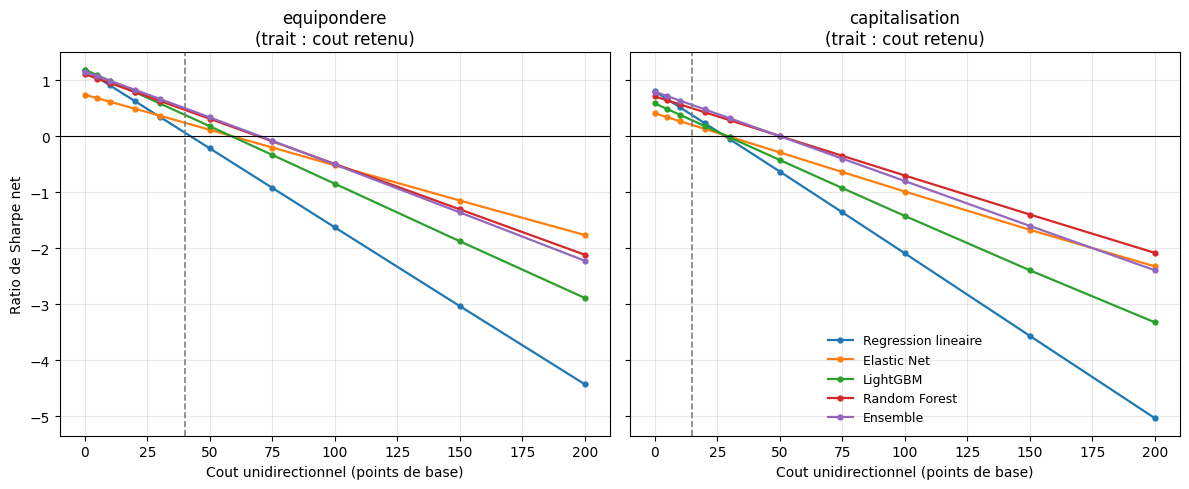

Figure sauvegardee : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\portefeuilles_sensibilite_couts.png


In [41]:
lignes_sensibilite = []
for (nom_modele, ponderation), resultat in resultats_couts.items():
    courbe = couts.sensibilite_aux_couts(
        resultat['rendement_brut'], resultat['turnover'], D_GRILLE_COUTS_BPS,
        cout_emprunt_annuel_bps=D_COUT_EMPRUNT_ANNUEL_BPS,
        calculer_metriques=portefeuilles.calculer_metriques)
    courbe.insert(0, 'ponderation', ponderation)
    courbe.insert(0, 'modele', nom_modele)
    lignes_sensibilite.append(courbe)

sensibilite = pd.concat(lignes_sensibilite, ignore_index=True)
sensibilite.to_parquet(config.FICHIER_SENSIBILITE_COUTS, index=False)

fig, axes = plt.subplots(1, len(D_PONDERATIONS), figsize=(6 * len(D_PONDERATIONS), 5),
                         sharey=True, squeeze=False)

for ax, ponderation in zip(axes[0], D_PONDERATIONS):
    bloc = sensibilite[sensibilite['ponderation'] == ponderation]
    for nom_modele in colonnes_decile:
        courbe = bloc[bloc['modele'] == nom_modele]
        ax.plot(courbe['cout_bps'], courbe['sharpe_ratio'], marker='o', markersize=3.5,
                linewidth=1.6, label=nom_modele)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(D_COUT_TRANSACTION_BPS.get(ponderation, 0.0), color='grey',
               linestyle='--', linewidth=1.2)
    ax.set_title(f"{ponderation}\n(trait : cout retenu)")
    ax.set_xlabel("Cout unidirectionnel (points de base)")
    ax.grid(alpha=0.3)

axes[0][0].set_ylabel("Ratio de Sharpe net")
axes[0][-1].legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(config.FICHIER_SENSIBILITE_COUTS_PNG, dpi=150)
plt.show()

print("Figure sauvegardee :", config.FICHIER_SENSIBILITE_COUTS_PNG)

### D.8 Les alphas, rejoués net de coûts

La question devient : **une fois les coûts payés, reste-t-il un alpha ?** Les quatre variantes
— équipondéré brut, équipondéré net, capi brut, capi net — passent dans la même régression
`FF5+MOM`, avec les mêmes écarts-types Newey-West.

C'est l'exercice d'Avramov, Cheng et Metzker : ils montrent qu'en imposant des contraintes
économiques réalistes aux stratégies de machine learning, les alphas s'effondrent souvent
jusqu'à la non-significativité. Si les vôtres résistent, le résultat est solide. S'ils tombent
sous 2 en t-stat, **c'est le résultat central du chapitre** — et c'en est un bon, pas un
échec.

In [42]:
variantes = {}
for (nom_modele, ponderation), resultat in resultats_couts.items():
    court = 'EW' if ponderation == 'equipondere' else 'VW'
    variantes[f"{nom_modele} [{court} brut]"] = resultat['rendement_brut']
    variantes[f"{nom_modele} [{court} net]"] = resultat['rendement_net']

alphas_nets = facteurs.alphas_par_portefeuille(
    variantes, fact, lags_newey_west=D_LAGS_NEWEY_WEST)

tableau_nets = facteurs.tableau_alphas_latex(alphas_nets, modele_factoriel=D_MODELE_FACTORIEL)
tableau_nets['alpha_annualise'] = tableau_nets['alpha_annualise'].round(2)

print(f"Alpha {D_MODELE_FACTORIEL} en % annualise, t-stat Newey-West :")
display(tableau_nets[['modele', 'alpha_annualise', 'alpha_t_stat',
                      'beta_mom', 'r2_facteurs', 'ratio_information']].round(3))

perdus = tableau_nets[tableau_nets['alpha_t_stat'].abs() < D_SEUIL_T]['modele'].tolist()
if perdus:
    print()
    print(f"⚠️ Alpha NON significatif (|t| < {D_SEUIL_T}) pour :")
    for nom in perdus:
        print("   -", nom)
    print("   C'est un resultat a part entiere, et il doit figurer tel quel dans le memoire.")
else:
    print()
    print(f"Tous les alphas restent significatifs a |t| > {D_SEUIL_T}, couts compris.")

Alpha FF5+MOM en % annualise, t-stat Newey-West :


,modele,alpha_annualise,alpha_t_stat,beta_mom,r2_facteurs,ratio_information
0,Regression lineaire [EW brut],10.17,4.096,0.526,0.410,1.246
1,Regression lineaire [EW net],-1.76,-0.713,0.523,0.410,-0.217
2,Elastic Net [EW brut],9.37,2.943,0.809,0.513,0.972
3,Elastic Net [EW net],2.43,0.766,0.800,0.510,0.253
4,LightGBM [EW brut],11.74,3.600,0.469,0.394,1.138
5,LightGBM [EW net],1.06,0.339,0.462,0.390,0.104
6,Random Forest [EW brut],13.80,4.394,0.547,0.480,1.360
7,Random Forest [EW net],4.82,1.559,0.540,0.479,0.477
8,Ensemble [EW brut],14.02,4.131,0.582,0.407,1.268
9,Ensemble [EW net],4.63,1.403,0.571,0.402,0.422



⚠️ Alpha NON significatif (|t| < 1.96) pour :
   - Regression lineaire [EW net]
   - Elastic Net [EW net]
   - LightGBM [EW net]
   - Random Forest [EW net]
   - Ensemble [EW net]
   - Regression lineaire [VW net]
   - Elastic Net [VW brut]
   - Elastic Net [VW net]
   - LightGBM [VW brut]
   - LightGBM [VW net]
   - Ensemble [VW net]
   C'est un resultat a part entiere, et il doit figurer tel quel dans le memoire.


**Résumé de la partie D.**

Les portefeuilles confrontés aux facteurs sous quatre angles : alphas emboîtés, comparaison
de Sharpe, turnover décomposé, et coûts. Ce qu'il faut regarder en priorité : le passage
équipondéré → capi, puis brut → net, puis les seuils de rentabilité.

⚠️ **Limites propres à cette partie.** Les coûts retenus sont des ordres de grandeur, pas des
mesures — d'où l'analyse de sensibilité, qui est le vrai résultat. Un coût proportionnel
uniforme ignore par ailleurs l'impact de marché, qui croît avec la taille des positions et
pénaliserait davantage une stratégie gérant des montants importants. Le coût d'emprunt
uniforme sous-estime le prix des titres difficiles à emprunter, précisément ceux qui peuplent
le décile 1. Et les facteurs de comparaison restent bruts de tout coût.

## Synthèse finale — précision statistique vs valeur économique

Les parties A et B évaluent les 4 modèles (et la partie C leur combinaison) sous deux angles différents : le `R²_oos` mesure
une précision statistique **par observation**, tandis que le ratio de Sharpe du portefeuille
long-short mesure une performance **économique agrégée**, une fois les prédictions traduites
en décisions d'achat/vente. Rien ne garantit *a priori* que les deux classements coïncident :
un modèle peut avoir un `R²_oos` très légèrement supérieur tout en se trompant plus souvent sur
les cas qui comptent le moins pour un portefeuille (le milieu du classement, les déciles 4 à 7),
et un peu moins souvent sur les extrêmes (déciles 1 et 10) qui sont les seuls à peser dans un
portefeuille long-short — c'est exactement le genre de nuance qu'un `R²_oos` global ne peut
pas capturer.

In [43]:
# Le portefeuille combine (partie C) est inclus : son R2_oos test a ete calcule en C.4 sur
# exactement les memes lignes que les modeles individuels.
r2_par_modele = resultats.set_index('modele')['r2_oos_test'].to_dict()
r2_par_modele[config.NOM_MODELE_ENSEMBLE] = r2_ensemble

synthese = pd.DataFrame({
    'r2_oos_test': pd.Series(r2_par_modele),
    'sharpe_ratio': performance['sharpe_ratio'],
}).dropna(subset=['sharpe_ratio'])

synthese['rang_r2_oos'] = synthese['r2_oos_test'].rank(ascending=False).astype(int)
synthese['rang_sharpe'] = synthese['sharpe_ratio'].rank(ascending=False).astype(int)
synthese = synthese.sort_values('rang_r2_oos')

print("Classement selon les deux angles d'evaluation (1 = meilleur), ensemble inclus :")
synthese.round(4)

Classement selon les deux angles d'evaluation (1 = meilleur), ensemble inclus :


,r2_oos_test,sharpe_ratio,rang_r2_oos,rang_sharpe
Ensemble,0.0056,1.1763,1,3
Random Forest,0.0049,1.1320,2,4
LightGBM,0.0048,1.2152,3,2
Elastic Net,0.0039,0.7657,4,5
Regression lineaire,0.0027,1.2200,5,1


In [44]:
classements_identiques = (synthese['rang_r2_oos'] == synthese['rang_sharpe']).all()

if classements_identiques:
    print("Les deux classements coincident parfaitement : le modele le plus precis")
    print("statistiquement est aussi celui qui degage le meilleur portefeuille ici.")
else:
    print("Les deux classements NE coincident PAS parfaitement :")
    for modele in synthese.index:
        r2, sh = synthese.loc[modele, 'rang_r2_oos'], synthese.loc[modele, 'rang_sharpe']
        if r2 != sh:
            print(f"  - {modele:22s} : rang {r2} en R2_oos, mais rang {sh} en Sharpe")
    print()
    print("Ce n'est pas anormal avec aussi peu de modeles (l'ecart peut venir du bruit")
    print("d'echantillonnage sur une seule periode de test), mais ca illustre bien pourquoi")
    print("il ne faut jamais choisir un modele sur la seule base du R2_oos en finance :")
    print("la performance economique realisee (deciles extremes, cout du risque...) peut")
    print("reordonner les modeles differemment de la precision statistique globale.")

Les deux classements NE coincident PAS parfaitement :
  - Ensemble               : rang 1 en R2_oos, mais rang 3 en Sharpe
  - Random Forest          : rang 2 en R2_oos, mais rang 4 en Sharpe
  - LightGBM               : rang 3 en R2_oos, mais rang 2 en Sharpe
  - Elastic Net            : rang 4 en R2_oos, mais rang 5 en Sharpe
  - Regression lineaire    : rang 5 en R2_oos, mais rang 1 en Sharpe

Ce n'est pas anormal avec aussi peu de modeles (l'ecart peut venir du bruit
d'echantillonnage sur une seule periode de test), mais ca illustre bien pourquoi
il ne faut jamais choisir un modele sur la seule base du R2_oos en finance :
la performance economique realisee (deciles extremes, cout du risque...) peut
reordonner les modeles differemment de la precision statistique globale.


⚠️ **Prudence sur cette synthèse** : avec aussi peu de modèles, un calcul de corrélation
de rang formel (Spearman) n'aurait pas vraiment de sens statistique — c'est pourquoi on se
contente ici d'une comparaison qualitative des deux classements. Sur un projet avec davantage
de modèles ou de sous-périodes de test, ce même exercice (croiser précision statistique et
performance économique réalisée) devient un diagnostic bien plus robuste.

## Résumé global

- **Partie A** : 4 modèles comparés sur `R²_oos` (train/validation/test, pooled sur toutes
  les fenêtres de chacun), avec diagnostic de sur-apprentissage via l'écart train/test, et
  évolution du R²_oos test fenêtre par fenêtre.
- **Partie B** : les mêmes 4 modèles traduits en portefeuilles long-short par décile
  (équipondérés, sur l'ensemble des prédictions de test déjà sauvegardées), évalués avec des
  mesures financières standard (Sharpe, Sortino, drawdown maximum, significativité
  statistique, monotonie par décile).
- **Partie C** : portefeuille **combiné** à partir des prédictions de plusieurs modèles
  (`config.MODELES_ENSEMBLE`), avec des poids fixes ou ré-estimés chaque mois sur le passé
  seulement — évalué exactement comme les autres, et enregistré comme une expérience à part
  entière (visible au notebook 09).
- **Partie D** : les mêmes portefeuilles confrontés aux facteurs de Fama-French augmentés du
  momentum — alphas emboîtés (CAPM → FF3 → FF5 → FF5+MOM) avec écarts-types Newey-West d'un
  côté, comparaison de Sharpe contre un portefeuille de facteurs de l'autre. Résultats dans
  `outputs/alphas_portefeuilles.parquet` et
  `outputs/comparaison_modeles_vs_facteurs.parquet`, hors journal des expériences.
- **Synthèse** : classements `R²_oos` et Sharpe comparés côte à côte — un rappel qu'un modèle
  statistiquement plus précis n'est pas automatiquement celui qui produit la meilleure
  stratégie d'investissement.
- Tous les résultats de ce notebook sont sauvegardés dans `outputs/` : comparaison des R²_oos,
  rendements mensuels et mesures de performance des portefeuilles.
